# Расчёт осевого компрессора
## По методике В.С. Бекнева (МВТУ им. Баумана, 1981)
### Комбинированный закон: $D_к = \text{const}$ → $D_{вт} = \text{const}$

**Разделы расчёта:**
1. Техническое задание
2. Предварительные оценки и параметрическая оптимизация
3. Предварительный расчёт проточной части
4. Распределение параметров по ступеням
5. Поступенчатый расчёт по средней линии тока
6. Профилирование решёток


In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6), 'font.size': 12,
    'axes.grid': True, 'grid.alpha': 0.3
})

# =============================================
# Газодинамические функции идеального газа
# =============================================

def tau_lam(lam, k=1.4):
    return 1.0 - (k - 1.0) / (k + 1.0) * lam**2

def eps_lam(lam, k=1.4):
    t = tau_lam(lam, k)
    if isinstance(t, np.ndarray):
        return np.where(t > 0, np.abs(t)**(1.0/(k-1.0)), 0.0)
    return t**(1.0/(k-1.0)) if t > 0 else 0.0

def q_lam(lam, k=1.4):
    t = tau_lam(lam, k)
    if isinstance(t, np.ndarray):
        return np.where(t > 0, lam * ((k+1)/2)**(1/(k-1)) * np.abs(t)**(1/(k-1)), 0.0)
    if t <= 0:
        return 0.0
    return lam * ((k+1)/2)**(1/(k-1)) * t**(1/(k-1))

def beta_coef(k=1.4):
    return np.sqrt(k) * (2.0/(k+1.0))**((k+1.0)/(2.0*(k-1.0)))

def a_cr_func(T_star, k=1.4, Rg=287.0):
    return np.sqrt(2.0*k/(k+1.0) * Rg * T_star)

# =============================================
# cp(T) и k(T) воздуха — полиномиальная аппроксимация
# T_bar = T / 1000 (температура в кК)
# =============================================
_CP_COEFFS = np.array([1.087192, -0.684074, 1.859839, -1.8104,
                        0.89029, -0.221403, 0.022161])

def cp_air(T, Rg=287.4):
    T_bar = T / 1000.0
    cp = np.polyval(_CP_COEFFS[::-1], T_bar) * 1000.0
    return cp

def k_air(T, Rg=287.4):
    cp = cp_air(T, Rg)
    return cp / (cp - Rg)

# Полиномиальные аппроксимации характеристик ступени (рис. 4)
def eta_stage_poly(ca_bar):
    return -2.454 * ca_bar**2 + 2.401 * ca_bar + 0.296

def HT_bar_poly(ca_bar):
    return -1.015 * ca_bar**2 + 0.408 * ca_bar + 0.344

print("Газодинамические функции загружены.")
print(f"  beta(k=1.4) = {beta_coef():.4f}")
print(f"  q(lam=0.5) = {q_lam(0.5):.4f}")
print(f"  q(lam=1.0) = {q_lam(1.0):.4f}")
print(f"\ncp(T) и k(T) воздуха:")
print(f"  cp(288 К) = {cp_air(288):.1f} Дж/(кг·К),  k(288 К) = {k_air(288):.4f}")
print(f"  cp(500 К) = {cp_air(500):.1f} Дж/(кг·К),  k(500 К) = {k_air(500):.4f}")
print(f"  cp(700 К) = {cp_air(700):.1f} Дж/(кг·К),  k(700 К) = {k_air(700):.4f}")

Газодинамические функции загружены.
  beta(k=1.4) = 0.6847
  q(lam=0.5) = 0.7091
  q(lam=1.0) = 1.0000

cp(T) и k(T) воздуха:
  cp(288 К) = 1006.9 Дж/(кг·К),  k(288 К) = 1.3994
  cp(500 К) = 1032.9 Дж/(кг·К),  k(500 К) = 1.3855
  cp(700 К) = 1077.8 Дж/(кг·К),  k(700 К) = 1.3636


## 1. Техническое задание (исходные данные)

In [102]:
# ================================================
# ИСХОДНЫЕ ДАННЫЕ (из README.md)
# ================================================
G = 58.7            # кг/с — массовый расход
T0_star = 288.0     # К — полная температура на входе
P0_star = 1.013e5   # Па — полное давление на входе
pi_k_star = 18.2    # степень повышения давления
n_rpm = 8600        # об/мин — частота вращения

# Свойства воздуха (переменные от температуры)
Rg = 287.4          # Дж/(кг·К)
k0 = k_air(T0_star, Rg)
cp0 = cp_air(T0_star, Rg)

# Для обратной совместимости: начальные значения k и cp (на входе)
k = k0
cp = cp0

# ================================================
# ПЕРЕКЛЮЧАТЕЛЬ ТИПА КОМПРЕССОРА
# ================================================
# "subsonic"    — дозвуковой   (Mw1 < 0.9,  Uk = 250–350 м/с)
# "transonic"   — околозвуковой (Mw1 = 0.9–1.1, Uk = 360–440 м/с)
# "supersonic"  — сверхзвуковой (Mw1 = 1.1–1.4, Uk = 450–490 м/с)
COMPRESSOR_TYPE = "subsonic"   # <-- ВЫБИРАЙТЕ ЗДЕСЬ

# Параметры ограничений в зависимости от типа
_type_params = {
    "subsonic":   {"Mw1_max": 0.90, "Uk_range": (200, 350), "Z_max": 25, "label": "Дозвуковой"},
    "transonic":  {"Mw1_max": 1.10, "Uk_range": (360, 440), "Z_max": 16, "label": "Околозвуковой"},
    "supersonic": {"Mw1_max": 1.40, "Uk_range": (450, 490), "Z_max": 14, "label": "Сверхзвуковой"},
}
assert COMPRESSOR_TYPE in _type_params, f"Неизвестный тип: {COMPRESSOR_TYPE}"

Mw1_LIMIT = _type_params[COMPRESSOR_TYPE]["Mw1_max"]
Uk_RANGE  = _type_params[COMPRESSOR_TYPE]["Uk_range"]
Z_MAX     = _type_params[COMPRESSOR_TYPE]["Z_max"]
TYPE_LABEL = _type_params[COMPRESSOR_TYPE]["label"]

# Форма проточной части: комбинированный закон
# Dk=const пока h >= 15мм и d_bar < 0.92, затем Dvt=const
FLOW_PATH = "combined"

# Пороги переключения на Dvt=const
H_MIN_MM = 15.0       # мм — минимальная высота лопатки
D_BAR_MAX = 0.92      # максимальный относительный диаметр втулки

# Убрать последнюю ступень (True — Z уменьшается на 1)
REMOVE_LAST_STAGE = False

# Коэффициенты потерь в патрубках (авиационный ГТД, осевые патрубки)
zeta_vkh = 0.04     # входной (осевой конфузорный)
zeta_vykh = 0.10    # выходной

# Скорости в патрубках
C_vkh = 165.0       # м/с — на выходе из входного патрубка
C_vykh = 120.0      # м/с — на входе в выходной патрубок

print(f"Рабочее тело: воздух (переменные cp, k)")
print(f"  Rg = {Rg} Дж/(кг·К)")
print(f"  cp(T*0={T0_star} К) = {cp0:.1f} Дж/(кг·К),  k(T*0) = {k0:.4f}")
print(f"G  = {G} кг/с")
print(f"T*0 = {T0_star} К       P*0 = {P0_star:.0f} Па")
print(f"pi*k = {pi_k_star}")
print(f"n  = {n_rpm} об/мин")
print(f"Тип проточной части: комбинированный (Dk=const → Dvt=const)")
print(f"  Переключение при: h < {H_MIN_MM} мм или d_bar >= {D_BAR_MAX}")
print(f"Тип компрессора:     {TYPE_LABEL} (Mw1 < {Mw1_LIMIT}, Uk = {Uk_RANGE[0]}–{Uk_RANGE[1]} м/с, Z ≤ {Z_MAX})")

Рабочее тело: воздух (переменные cp, k)
  Rg = 287.4 Дж/(кг·К)
  cp(T*0=288.0 К) = 1006.9 Дж/(кг·К),  k(T*0) = 1.3994
G  = 58.7 кг/с
T*0 = 288.0 К       P*0 = 101300 Па
pi*k = 18.2
n  = 8600 об/мин
Тип проточной части: комбинированный (Dk=const → Dvt=const)
  Переключение при: h < 15.0 мм или d_bar >= 0.92
Тип компрессора:     Дозвуковой (Mw1 < 0.9, Uk = 200–350 м/с, Z ≤ 25)


## 2. Предварительные оценки

Оцениваем КПД компрессора через политропический КПД по формуле:
$$\eta^*_к = \frac{\pi_к^{*(k-1)/k} - 1}{\pi_к^{*(k-1)/(k \cdot \eta_{\text{пол}})} - 1}$$


In [103]:
# ================================================
# ПРЕДВАРИТЕЛЬНЫЕ ОЦЕНКИ (с переменными cp, k)
# ================================================

# Политропический КПД
eta_pol = 0.90

# Итерация: k и cp зависят от температуры, а T_k_star зависит от k и cp
k_avg = k0
cp_avg = cp0
for _iter in range(20):
    eta_k_star_est = (pi_k_star**((k_avg-1)/k_avg) - 1) / (pi_k_star**((k_avg-1)/(k_avg*eta_pol)) - 1)
    T_k_star = T0_star * (1 + (pi_k_star**((k_avg-1)/k_avg) - 1) / eta_k_star_est)
    k_avg_new = k_air(0.5*(T0_star + T_k_star), Rg)
    cp_avg_new = cp_air(0.5*(T0_star + T_k_star), Rg)
    if abs(k_avg_new - k_avg) < 1e-6:
        k_avg = k_avg_new
        cp_avg = cp_avg_new
        break
    k_avg = k_avg_new
    cp_avg = cp_avg_new

k_vykh = k_air(T_k_star, Rg)
cp_vykh = cp_air(T_k_star, Rg)

# Критические скорости в патрубках (с локальными k)
a_cr_vkh = a_cr_func(T0_star, k=k0, Rg=Rg)
a_cr_vykh = a_cr_func(T_k_star, k=k_vykh, Rg=Rg)

# Приведённые скорости
lam_vkh = C_vkh / a_cr_vkh
lam_vykh = C_vykh / a_cr_vykh

# Коэффициенты сохранения полного давления (с локальными k)
sigma_vkh = 1.0 / (1.0 + zeta_vkh * k0/(k0+1) * eps_lam(lam_vkh, k0) * lam_vkh**2)
sigma_vykh = 1.0 - zeta_vykh * k_vykh/(k_vykh+1) * eps_lam(lam_vykh, k_vykh) * lam_vykh**2

# Полные давления на границах лопаточного аппарата
P1_star = sigma_vkh * P0_star
P_k_out = pi_k_star * P0_star
P2_star = P_k_out / sigma_vykh

# Степень повышения давления лопаточного аппарата
pi_la = P2_star / P1_star

# Коэффициент C и КПД лопаточного аппарата
C_coef = (pi_k_star**((k_avg-1)/k_avg) - 1) / (pi_la**((k_avg-1)/k_avg) - 1)
eta_la = eta_k_star_est / C_coef

# Адиабатический напор компрессора
H_ad_k = cp_avg * T0_star * (pi_k_star**((k_avg-1)/k_avg) - 1)
# Суммарный теоретический напор
H_tk = H_ad_k / eta_k_star_est

# Площади сечений в патрубках (с локальными k)
beta_vkh = beta_coef(k0)
beta_vykh = beta_coef(k_vykh)
F_vkh_area = G * np.sqrt(Rg * T0_star) / (beta_vkh * P1_star * q_lam(lam_vkh, k0))
F_vykh_area = G * np.sqrt(Rg * T_k_star) / (beta_vykh * P2_star * q_lam(lam_vykh, k_vykh))

# beta_k_val для совместимости (используется далее)
beta_k_val = beta_vkh

print("=== ПРЕДВАРИТЕЛЬНЫЕ ОЦЕНКИ (переменные cp, k) ===")
print(f"k_вх    = {k0:.4f}          cp_вх   = {cp0:.1f} Дж/(кг·К)")
print(f"k_ср    = {k_avg:.4f}          cp_ср   = {cp_avg:.1f} Дж/(кг·К)")
print(f"k_вых   = {k_vykh:.4f}          cp_вых  = {cp_vykh:.1f} Дж/(кг·К)")
print(f"eta_pol = {eta_pol}")
print(f"eta*k   = {eta_k_star_est:.4f}")
print(f"T*k     = {T_k_star:.1f} К")
print(f"a_cr_вх = {a_cr_vkh:.1f} м/с    a_cr_вых = {a_cr_vykh:.1f} м/с")
print(f"lam_вх  = {lam_vkh:.4f}       lam_вых  = {lam_vykh:.4f}")
print(f"sigma_вх  = {sigma_vkh:.4f}     sigma_вых  = {sigma_vykh:.4f}")
print(f"P*1     = {P1_star:.0f} Па    P*2     = {P2_star:.0f} Па")
print(f"pi*_ла  = {pi_la:.3f}")
print(f"C       = {C_coef:.4f}     eta*_ла = {eta_la:.4f}")
print(f"H*_ад_к = {H_ad_k/1000:.1f} кДж/кг")
print(f"H_тк    = {H_tk/1000:.1f} кДж/кг")
print(f"F_вх    = {F_vkh_area:.4f} м²    F_вых    = {F_vykh_area:.4f} м²")

=== ПРЕДВАРИТЕЛЬНЫЕ ОЦЕНКИ (переменные cp, k) ===
k_вх    = 1.3994          cp_вх   = 1006.9 Дж/(кг·К)
k_ср    = 1.3858          cp_ср   = 1032.4 Дж/(кг·К)
k_вых   = 1.3629          cp_вых  = 1079.4 Дж/(кг·К)
eta_pol = 0.9
eta*k   = 0.8551
T*k     = 706.6 К
a_cr_вх = 310.7 м/с    a_cr_вых = 484.0 м/с
lam_вх  = 0.5310       lam_вых  = 0.2479
sigma_вх  = 0.9942     sigma_вых  = 0.9965
P*1     = 100713 Па    P*2     = 1850050 Па
pi*_ла  = 18.370
C       = 0.9954     eta*_ла = 0.8591
H*_ад_к = 369.5 кДж/кг
H_тк    = 432.1 кДж/кг
F_вх    = 0.3298 м²    F_вых    = 0.0551 м²


## 3. Параметрическая оптимизация

Ищем оптимальные значения $\bar{c}_{a_1}$ и $\bar{d}_1$ перебором по сетке.

**Закон профилирования:** комбинированный — сначала $D_к = \text{const}$, переход на $D_{вт} = \text{const}$ при:
- высоте лопатки $h < 15$ мм, или
- относительном диаметре втулки $\bar{d} \geq 0.92$

**Ограничения:**
- $M_{w_1}$ на конце лопатки — в пределах выбранного типа компрессора
- $u_к$ — в допустимом диапазоне окружных скоростей для типа
- Высота лопатки последней ступени $h_n > 15$ мм (с учётом комбинированного закона)
- Относительный диаметр втулки последней ступени $\bar{d}_n < 0.92$
- Число ступеней $Z$ — ограничено в зависимости от типа

**Целевая функция:** максимизация $\eta^*_{ст} - 0.002 \cdot Z$ (баланс КПД и числа ступеней).


In [104]:
def compute_preliminary_design(ca_bar_1, d_bar_1, R_sr=0.5):
    # Предварительный расчёт для заданных ca_bar_1 и d_bar_1.
    # Комбинированный закон: Dk=const → Dvt=const.
    # Возвращает dict с результатами или None.
    tau_sr1 = np.sqrt((1.0 + d_bar_1**2) / 2.0)
    HT_bar = HT_bar_poly(ca_bar_1)
    if HT_bar <= 0:
        return None
    cu_bar1 = tau_sr1 * (1.0 - R_sr) - HT_bar / (2.0 * tau_sr1)

    k_loc = k0  # k на входе (1-я ступень)

    # Итерация для u_k
    u_k = (Uk_RANGE[0] + Uk_RANGE[1]) / 2.0
    for _ in range(200):
        c1 = u_k * np.sqrt(ca_bar_1**2 + cu_bar1**2)
        lam1 = c1 / a_cr_vkh
        if lam1 >= np.sqrt((k_loc+1)/(k_loc-1)) * 0.99:
            return None
        rho1 = P1_star / (Rg * T0_star) * eps_lam(lam1, k_loc)
        if rho1 <= 0:
            return None
        u_k_new = (4.0 * np.pi * G * (n_rpm/60.0)**2 /
                   (ca_bar_1 * rho1 * (1.0 - d_bar_1**2)))**(1.0/3.0)
        if abs(u_k_new - u_k) < 0.001:
            u_k = u_k_new
            break
        u_k = 0.5 * u_k + 0.5 * u_k_new

    D_k = 60.0 * u_k / (np.pi * n_rpm)
    h_1 = 0.5 * D_k * (1.0 - d_bar_1)

    # Число ступеней
    HT_bar_avg = 0.28
    Z = int(np.ceil(H_tk / (HT_bar_avg * u_k**2)))
    Z = max(Z, 4)

    # Последняя ступень — комбинированный закон
    # Сначала пробуем Dk=const
    D_vt_n_sq = D_k**2 - 4.0 * F_vykh_area / np.pi
    if D_vt_n_sq < 0:
        return None
    d_bar_n_dk = np.sqrt(D_vt_n_sq) / D_k
    h_n_dk = 0.5 * D_k * (1.0 - d_bar_n_dk)

    # Если нарушены ограничения → переход на Dvt=const
    if d_bar_n_dk >= D_BAR_MAX or h_n_dk * 1000 < H_MIN_MM:
        # Определяем d_bar на момент переключения (чуть ниже порога)
        d_bar_switch = min(D_BAR_MAX - 0.02, d_bar_n_dk - 0.02)
        d_bar_switch = max(d_bar_switch, d_bar_1 + 0.05)
        D_vt_switch = d_bar_switch * D_k
        # С Dvt=const: Dk_exit = sqrt(Dvt² + 4*F_exit/π)
        D_k_exit = np.sqrt(D_vt_switch**2 + 4.0 * F_vykh_area / np.pi)
        d_bar_n = D_vt_switch / D_k_exit
        h_n = (D_k_exit - D_vt_switch) / 2.0
    else:
        d_bar_n = d_bar_n_dk
        h_n = h_n_dk

    # M_w1 на конце лопатки
    ca1 = ca_bar_1 * u_k
    cu1_sr = cu_bar1 * u_k
    u_sr = tau_sr1 * u_k
    cu1_tip = cu1_sr * tau_sr1  # C_u*r=const => C_u_tip = C_u_sr * r_sr/r_k = C_u_sr * tau_sr
    w1_tip = np.sqrt(ca1**2 + (u_k - cu1_tip)**2)
    T1_stat = T0_star * tau_lam(lam1, k_loc)
    if T1_stat <= 0:
        return None
    a1 = np.sqrt(k_loc * Rg * T1_stat)
    Mw1_tip = w1_tip / a1

    w1_sr = np.sqrt(ca1**2 + (u_sr - cu1_sr)**2)
    Mw1_sr = w1_sr / a1

    return {
        'u_k': u_k, 'D_k': D_k, 'h_1': h_1, 'h_n': h_n, 'Z': Z,
        'Mw1_tip': Mw1_tip, 'Mw1_sr': Mw1_sr,
        'd_bar_n': d_bar_n, 'eta_st': eta_stage_poly(ca_bar_1),
        'HT_bar': HT_bar, 'ca_bar_1': ca_bar_1, 'd_bar_1': d_bar_1,
        'rho1': rho1, 'cu_bar1': cu_bar1, 'tau_sr1': tau_sr1,
        'lam1': lam1, 'ca1': ca1,
    }

# Сетка параметров (расширенная для поиска допустимой области)
ca_range = np.linspace(0.45, 0.65, 80)
d_range = np.linspace(0.5, 0.65, 80)

obj_grid = np.full((len(d_range), len(ca_range)), np.nan)
Z_grid = np.full_like(obj_grid, np.nan)
Mw1_grid = np.full_like(obj_grid, np.nan)
hn_grid = np.full_like(obj_grid, np.nan)
dn_grid = np.full_like(obj_grid, np.nan)
uk_grid = np.full_like(obj_grid, np.nan)
eta_grid = np.full_like(obj_grid, np.nan)

for i, d_b in enumerate(d_range):
    for j, ca_b in enumerate(ca_range):
        res = compute_preliminary_design(ca_b, d_b)
        if res is None:
            continue
        Z_grid[i,j] = res['Z']
        Mw1_grid[i,j] = res['Mw1_tip']
        hn_grid[i,j] = res['h_n'] * 1000
        dn_grid[i,j] = res['d_bar_n']
        uk_grid[i,j] = res['u_k']
        eta_grid[i,j] = res['eta_st']
        # Проверка ограничений
        if (res['Mw1_tip'] < Mw1_LIMIT and res['h_n']*1000 > H_MIN_MM and
                res['d_bar_n'] < D_BAR_MAX and res['Z'] <= Z_MAX and
                Uk_RANGE[0] <= res['u_k'] <= Uk_RANGE[1]):
            obj_grid[i,j] = res['eta_st'] - 0.002 * res['Z']

# Оптимум
if np.any(~np.isnan(obj_grid)):
    opt_idx = np.unravel_index(np.nanargmax(obj_grid), obj_grid.shape)
    ca_opt = ca_range[opt_idx[1]]
    d_opt = d_range[opt_idx[0]]
    res_opt = compute_preliminary_design(ca_opt, d_opt)
    print("=" * 60)
    print("ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ 1-й СТУПЕНИ")
    print("=" * 60)
    print(f"  c_a_bar = {ca_opt:.4f}")
    print(f"  d_bar_1 = {d_opt:.4f}")
    print(f"  u_k     = {res_opt['u_k']:.1f} м/с")
    print(f"  D_k     = {res_opt['D_k']*1000:.0f} мм")
    print(f"  h_1     = {res_opt['h_1']*1000:.1f} мм")
    print(f"  h_n     = {res_opt['h_n']*1000:.1f} мм")
    print(f"  Z       = {res_opt['Z']}")
    print(f"  M_w1_tip= {res_opt['Mw1_tip']:.3f}")
    print(f"  M_w1_sr = {res_opt['Mw1_sr']:.3f}")
    print(f"  eta*_st = {res_opt['eta_st']:.4f}")
    print(f"  H_T_bar = {res_opt['HT_bar']:.4f}")
    print(f"  d_bar_n = {res_opt['d_bar_n']:.4f}")
else:
    print("Допустимая область не найдена!")
    print()
    # Диагностика: ищем ближайшую точку и показываем, какие ограничения нарушены
    print("Диагностика — ближайшие точки (минимум нарушений):")
    best_points = []
    for i, d_b in enumerate(d_range):
        for j, ca_b in enumerate(ca_range):
            res = compute_preliminary_design(ca_b, d_b)
            if res is None:
                continue
            violations = []
            if res['Mw1_tip'] >= Mw1_LIMIT:
                violations.append(f"Mw1={res['Mw1_tip']:.3f}>={Mw1_LIMIT}")
            if res['h_n']*1000 <= H_MIN_MM:
                violations.append(f"h_n={res['h_n']*1000:.1f}mm<={H_MIN_MM}")
            if res['d_bar_n'] >= D_BAR_MAX:
                violations.append(f"d_n={res['d_bar_n']:.3f}>={D_BAR_MAX}")
            if res['Z'] > Z_MAX:
                violations.append(f"Z={res['Z']}>{Z_MAX}")
            if res['u_k'] < Uk_RANGE[0]:
                violations.append(f"uk={res['u_k']:.0f}<{Uk_RANGE[0]}")
            if res['u_k'] > Uk_RANGE[1]:
                violations.append(f"uk={res['u_k']:.0f}>{Uk_RANGE[1]}")
            if len(violations) > 0:
                best_points.append((len(violations), ca_b, d_b, res, violations))
    best_points.sort(key=lambda x: x[0])
    for nv, ca_b, d_b, res, viol in best_points[:5]:
        print(f"  ca={ca_b:.3f} d={d_b:.3f}: uk={res['u_k']:.0f} Z={res['Z']} "
              f"Mw1={res['Mw1_tip']:.3f} h_n={res['h_n']*1000:.1f} d_n={res['d_bar_n']:.3f} | "
              f"НАРУШЕНИЯ: {', '.join(viol)}")
    print()
    print("Рекомендация: смените тип на 'transonic' или скорректируйте ограничения.")
    # Fallback: берём лучшую точку с минимумом нарушений
    if best_points:
        _, ca_opt, d_opt, res_opt, _ = best_points[0]
        print(f"\n>>> Используем ближайшую точку для продолжения расчёта:")
        print(f"    ca_bar={ca_opt:.4f}, d_bar={d_opt:.4f}, u_k={res_opt['u_k']:.1f}")
    else:
        ca_opt, d_opt = 0.50, 0.45
        res_opt = compute_preliminary_design(ca_opt, d_opt)

Допустимая область не найдена!

Диагностика — ближайшие точки (минимум нарушений):
  ca=0.450 d=0.500: uk=347 Z=13 Mw1=1.006 h_n=24.4 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.006>=0.9, d_n=0.934>=0.92
  ca=0.453 d=0.500: uk=347 Z=13 Mw1=1.005 h_n=24.4 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.005>=0.9, d_n=0.934>=0.92
  ca=0.455 d=0.500: uk=346 Z=13 Mw1=1.004 h_n=24.5 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.004>=0.9, d_n=0.934>=0.92
  ca=0.458 d=0.500: uk=346 Z=13 Mw1=1.004 h_n=24.5 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.004>=0.9, d_n=0.934>=0.92
  ca=0.460 d=0.500: uk=345 Z=13 Mw1=1.003 h_n=24.5 d_n=0.934 | НАРУШЕНИЯ: Mw1=1.003>=0.9, d_n=0.934>=0.92

Рекомендация: смените тип на 'transonic' или скорректируйте ограничения.

>>> Используем ближайшую точку для продолжения расчёта:
    ca_bar=0.4500, d_bar=0.5000, u_k=347.4


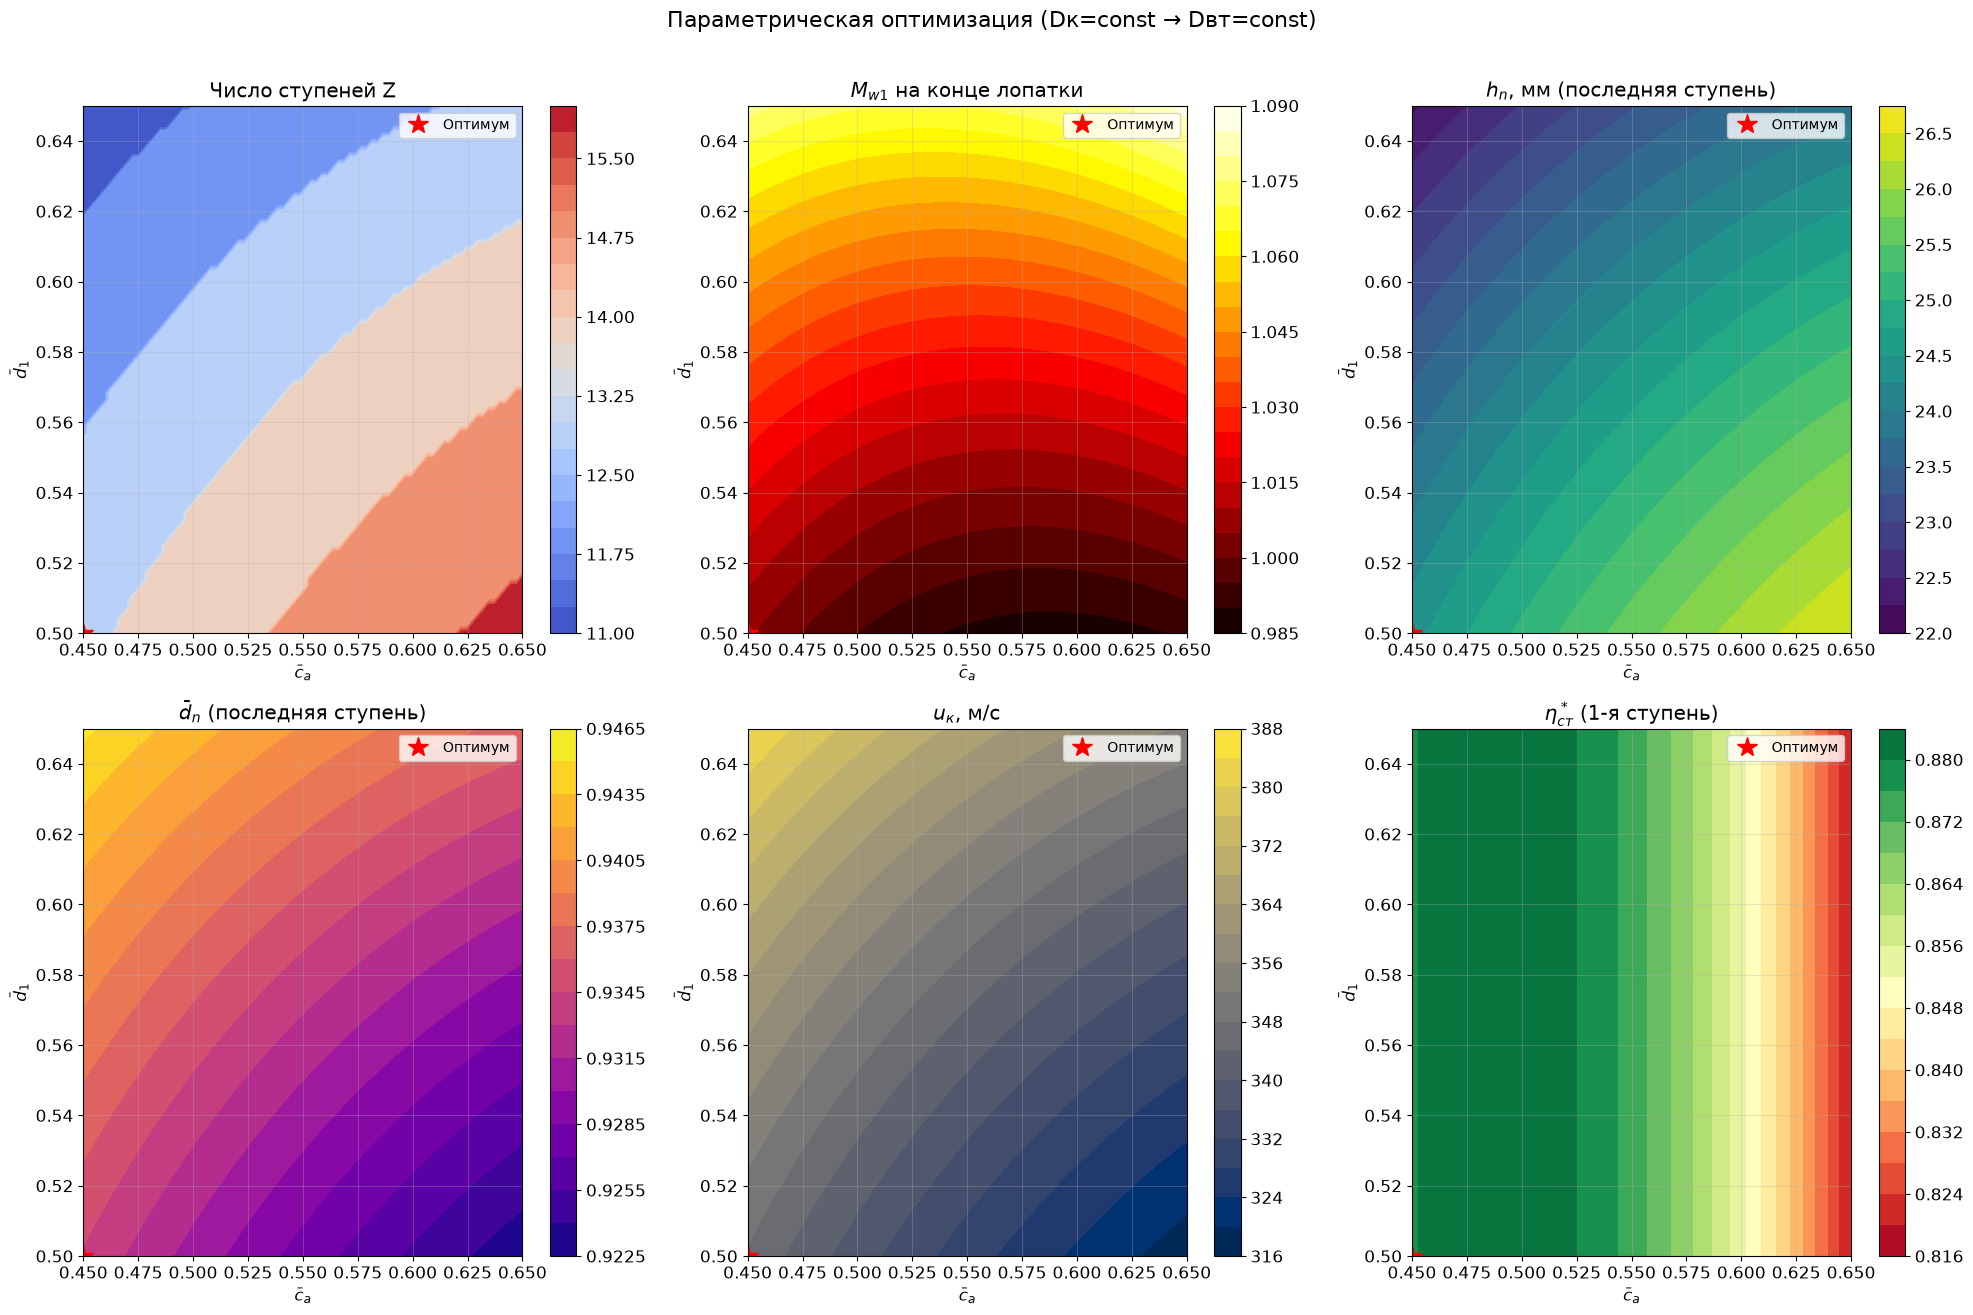

In [105]:
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
CA, DB = np.meshgrid(ca_range, d_range)

data_list = [
    (Z_grid, 'Число ступеней Z', 'coolwarm'),
    (Mw1_grid, '$M_{w1}$ на конце лопатки', 'hot'),
    (hn_grid, '$h_n$, мм (последняя ступень)', 'viridis'),
    (dn_grid, '$\\bar{d}_n$ (последняя ступень)', 'plasma'),
    (uk_grid, '$u_к$, м/с', 'cividis'),
    (eta_grid, '$\\eta^*_{ст}$ (1-я ступень)', 'RdYlGn'),
]

for ax, (dat, title, cmap) in zip(axes.flat, data_list):
    mask = ~np.isnan(dat)
    if mask.any():
        cs = ax.contourf(CA, DB, dat, levels=20, cmap=cmap)
        plt.colorbar(cs, ax=ax)
    ax.set_xlabel('$\\bar{c}_a$')
    ax.set_ylabel('$\\bar{d}_1$')
    ax.set_title(title)
    ax.plot(ca_opt, d_opt, 'r*', markersize=15, label='Оптимум')
    ax.legend(fontsize=10)

plt.suptitle('Параметрическая оптимизация (Dк=const → Dвт=const)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## 4. Предварительный расчёт проточной части

Формулы по п. 2.3 методики:
$$u_{к_1} = \sqrt[3]{\frac{\pi \cdot G \cdot n^2}{900 \cdot \bar{c}_{a_1} \cdot \rho_1 \cdot (1 - \bar{d}_1^2)}}$$
$$D_{к_1} = \frac{60 \cdot u_{к_1}}{\pi \cdot n}$$
$$h_1 = \frac{1}{2} D_{к_1}(1 - \bar{d}_1)$$


In [106]:


# Фиксируем оптимальные параметры
ca_bar_1 = ca_opt
d_bar_1 = d_opt
R_sr_base = 0.5

design = compute_preliminary_design(ca_bar_1, d_bar_1, R_sr_base)

u_k = design['u_k']
D_k = design['D_k']
D_vt_1 = d_bar_1 * D_k
tau_sr1 = design['tau_sr1']
D_sr_1 = tau_sr1 * D_k
h_1 = design['h_1']
h_n = design['h_n']
Z = design['Z']
if REMOVE_LAST_STAGE and Z > 4:
    Z -= 1
    print(f"REMOVE_LAST_STAGE = True → Z уменьшено: {Z+1} → {Z}")
d_bar_n = design['d_bar_n']
HT_bar_1 = design['HT_bar']

print("=" * 60)
print("РАЗМЕРЫ ПРОТОЧНОЙ ЧАСТИ")
print("=" * 60)
print(f"u_k     = {u_k:.2f} м/с")
print(f"D_k     = {D_k*1000:.1f} мм")
print(f"D_вт_1  = {D_vt_1*1000:.1f} мм")
print(f"D_ср_1  = {D_sr_1*1000:.1f} мм")
print(f"h_1     = {h_1*1000:.1f} мм")
print(f"h_n     = {h_n*1000:.1f} мм")
print(f"d_bar_1 = {d_bar_1:.4f}")
print(f"d_bar_n = {d_bar_n:.4f}")
print(f"Z       = {Z} ступеней")
print(f"ca_1    = {ca_bar_1*u_k:.1f} м/с")
print()
print(f"F_вх    = {F_vkh_area:.4f} м²  (площадь на выходе вх. патрубка)")
print(f"F_вых   = {F_vykh_area:.4f} м²  (площадь на входе вых. патрубка)")
print(f"F_1     = {np.pi/4*D_k**2*(1-d_bar_1**2):.4f} м²  (кольцевая площадь 1-й ступени)")


РАЗМЕРЫ ПРОТОЧНОЙ ЧАСТИ
u_k     = 347.43 м/с
D_k     = 771.6 мм
D_вт_1  = 385.8 мм
D_ср_1  = 610.0 мм
h_1     = 192.9 мм
h_n     = 24.4 мм
d_bar_1 = 0.5000
d_bar_n = 0.9343
Z       = 13 ступеней
ca_1    = 156.3 м/с

F_вх    = 0.3298 м²  (площадь на выходе вх. патрубка)
F_вых   = 0.0551 м²  (площадь на входе вых. патрубка)
F_1     = 0.3507 м²  (кольцевая площадь 1-й ступени)


## 4.1 Входной направляющий аппарат (ВНА)

Коэффициент сохранения полного давления в ВНА:
$$\sigma_{\mathrm{ВНА}} = 0.993$$

Направление абсолютной скорости на выходе из ВНА:
$$\alpha_{2\,\mathrm{ВНА}} = \arctan\left(\frac{\bar{c}_{a1}}{\bar{c}_{u1}}\right)$$

In [107]:
# ================================================
# ВХОДНОЙ НАПРАВЛЯЮЩИЙ АППАРАТ (ВНА)
# ================================================

sigma_VNA = sigma_vkh

# Полное давление на входе и выходе из ВНА
P0_star_VNA = P0_star
P1_star_VNA = sigma_VNA * P0_star_VNA

# Коэффициенты скорости из предварительного расчёта
ca1_bar_vna = ca_bar_1
cu1_bar_vna = design['cu_bar1']

# Углы
alpha1_VNA = 90.0  # на входе — осевой поток
alpha2_VNA = np.degrees(np.arctan2(ca1_bar_vna, cu1_bar_vna))

print("=== ВХОДНОЙ НАПРАВЛЯЮЩИЙ АППАРАТ (ВНА) ===")
print(f"sigma_ВНА     = {sigma_VNA}")
print(f"P*0 (вход)    = {P0_star_VNA:.0f} Па")
print(f"P*1 (выход)   = {P1_star_VNA:.3f} Па")
print(f"c_a1_bar      = {ca1_bar_vna:.4f}")
print(f"c_u1_bar      = {cu1_bar_vna:.4f}")
print(f"α_1 ВНА (вход)  = {alpha1_VNA:.0f}°")
print(f"α_2 ВНА (выход) = {alpha2_VNA:.3f}°")

=== ВХОДНОЙ НАПРАВЛЯЮЩИЙ АППАРАТ (ВНА) ===
sigma_ВНА     = 0.9942014535697086
P*0 (вход)    = 101300 Па
P*1 (выход)   = 100712.607 Па
c_a1_bar      = 0.4500
c_u1_bar      = 0.1916
α_1 ВНА (вход)  = 90°
α_2 ВНА (выход) = 66.937°


## 5. Распределение параметров по ступеням

По п. 2.2 методики:
- $\bar{c}_a$ — плавное снижение от 1-й к последней ступени
- $\eta^*_a$ — максимум в средних ступенях, снижение к краям
- $\bar{H}_т$ — колоколообразное распределение
- $R_{ср}$ — 0.5, с повышением к последним ступеням
- $K_н$ — линейное убывание (влияние вязкости)


In [108]:
stages = np.arange(1, Z + 1)

# ---- c_a_bar: плавное убывание ----
ca_bar_last = max(0.36, ca_bar_1 - 0.018 * (Z - 1))
ca_bar_dist = ca_bar_1 - (ca_bar_1 - ca_bar_last) * ((stages - 1) / max(Z - 1, 1))**0.75

# ---- eta*: из полинома с коррекцией для первых/последних ступеней ----
eta_dist = np.array([eta_stage_poly(c) for c in ca_bar_dist])
eta_corr = np.ones(Z)
eta_corr[0] = 0.975
if Z > 1: eta_corr[1] = 0.988
if Z > 2: eta_corr[-1] = 0.975
if Z > 3: eta_corr[-2] = 0.988
eta_dist = eta_dist * eta_corr

# ---- H_T_bar: из полинома с коррекцией ----
HT_bar_dist = np.array([HT_bar_poly(c) for c in ca_bar_dist])
ht_corr = np.ones(Z)
ht_corr[0] = 0.88
if Z > 1: ht_corr[1] = 0.94
if Z > 2: ht_corr[-1] = 0.90
if Z > 3: ht_corr[-2] = 0.95
HT_bar_dist = HT_bar_dist * ht_corr

# ---- R_sr ----
R_dist = np.full(Z, 0.5)
if Z > 3:
    R_dist[-1] = 0.55
    R_dist[-2] = 0.52

# ---- K_H (поправочный коэффициент) ----
K_H_dist = np.linspace(0.99, max(0.94, 0.99 - 0.005 * (Z - 1)), Z)

# ---- Delta_Ca: изменение осевой скорости в ступени, м/с ----
delta_Ca_dist = np.linspace(6, 10, Z)

# ---- Масштабирование HT_bar для совпадения суммарного напора с H_tk ----
# Оценка суммарного теоретического напора от текущего распределения
H_tk_dist = np.sum(HT_bar_dist) * u_k**2
scale_HT = H_tk / H_tk_dist
HT_bar_dist = HT_bar_dist * scale_HT
print(f"Масштабирование HT_bar: scale = {scale_HT:.4f}  (H_tk_расп = {H_tk_dist/1000:.1f}, H_tk_цель = {H_tk/1000:.1f} кДж/кг)")

# Вывод таблицы
print(f"{'Ступень':>8} {'ca_bar':>8} {'HT_bar':>8} {'eta*':>8} {'R':>6} {'K_H':>6} {'dCa':>6}")
print("-" * 60)
for i in range(Z):
    print(f"{i+1:>8d} {ca_bar_dist[i]:>8.4f} {HT_bar_dist[i]:>8.4f} {eta_dist[i]:>8.4f} "
          f"{R_dist[i]:>6.3f} {K_H_dist[i]:>6.3f} {delta_Ca_dist[i]:>6.1f}")


Масштабирование HT_bar: scale = 0.8202  (H_tk_расп = 526.9, H_tk_цель = 432.1 кДж/кг)
 Ступень   ca_bar   HT_bar     eta*      R    K_H    dCa
------------------------------------------------------------
       1   0.4500   0.2325   0.8575  0.500  0.990    6.0
       2   0.4360   0.2536   0.8658  0.500  0.986    6.3
       3   0.4265   0.2734   0.8736  0.500  0.982    6.7
       4   0.4182   0.2765   0.8709  0.500  0.978    7.0
       5   0.4105   0.2792   0.8681  0.500  0.973    7.3
       6   0.4033   0.2817   0.8652  0.500  0.969    7.7
       7   0.3965   0.2840   0.8622  0.500  0.965    8.0
       8   0.3899   0.2861   0.8591  0.500  0.961    8.3
       9   0.3836   0.2880   0.8559  0.500  0.957    8.7
      10   0.3775   0.2898   0.8526  0.500  0.952    9.0
      11   0.3715   0.2916   0.8493  0.500  0.948    9.3
      12   0.3657   0.2785   0.8357  0.520  0.944    9.7
      13   0.3600   0.2652   0.8213  0.550  0.940   10.0


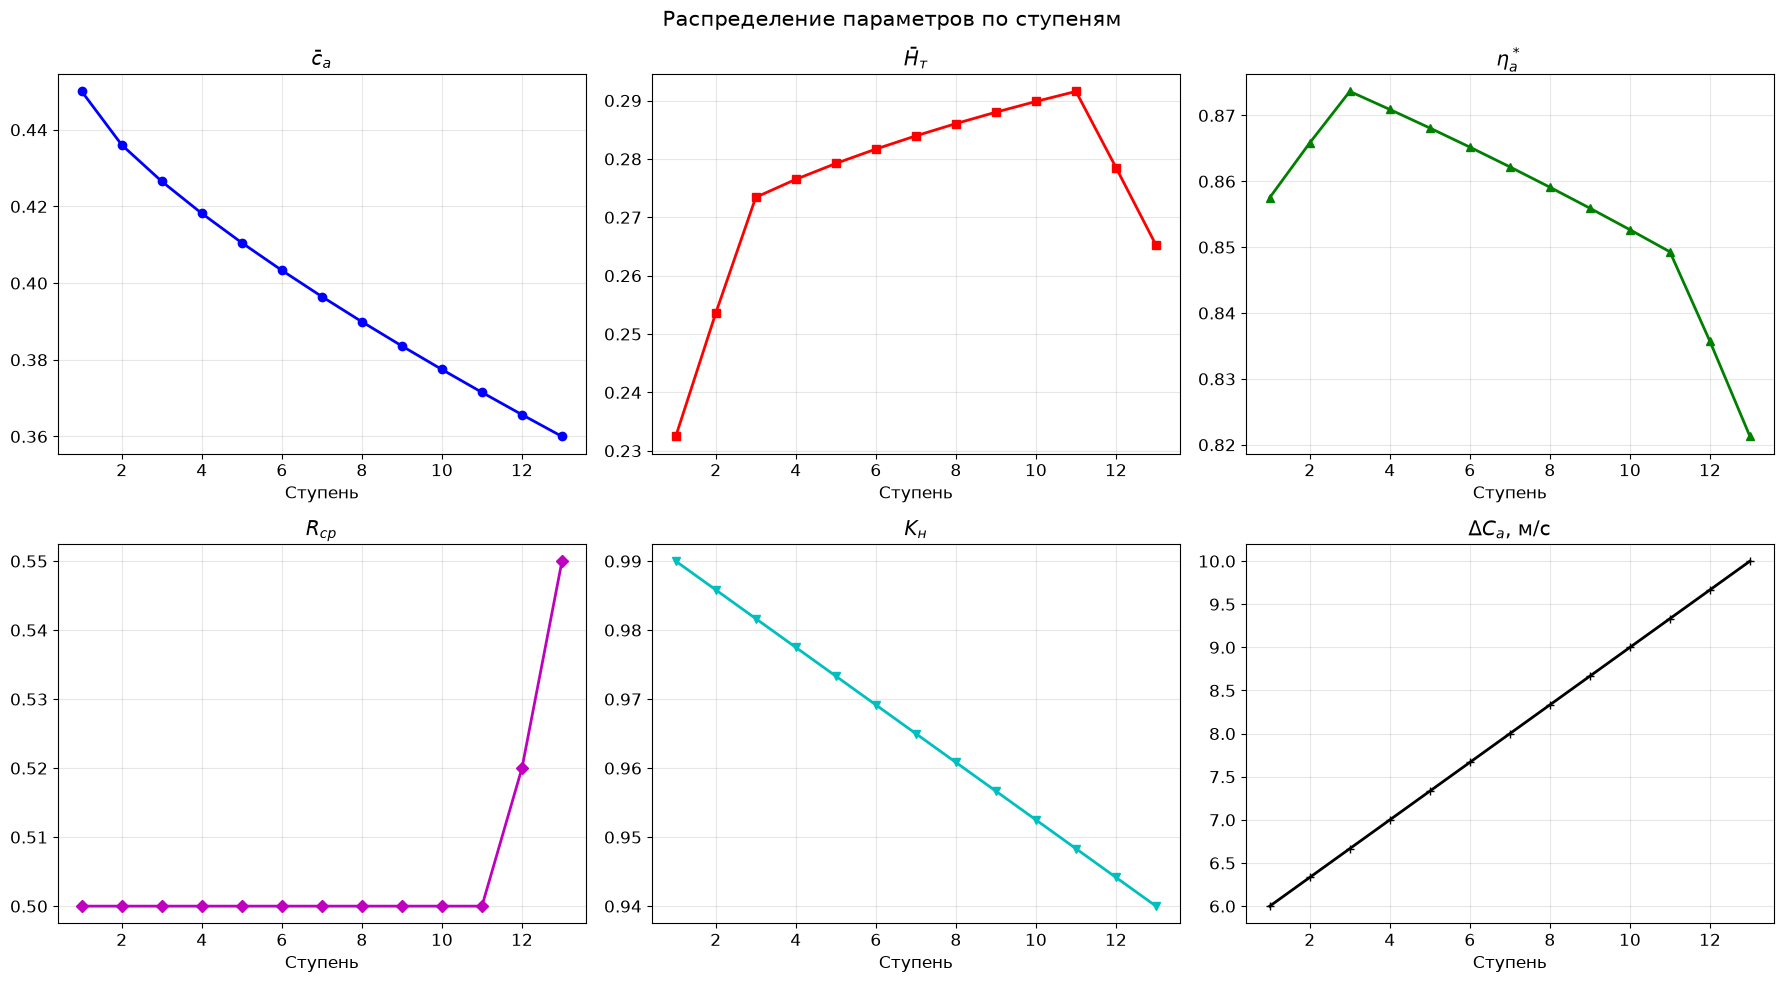

In [109]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(stages, ca_bar_dist, 'bo-', lw=2)
axes[0,0].set_title('$\\bar{c}_a$')
axes[0,0].set_xlabel('Ступень')

axes[0,1].plot(stages, HT_bar_dist, 'rs-', lw=2)
axes[0,1].set_title('$\\bar{H}_т$')
axes[0,1].set_xlabel('Ступень')

axes[0,2].plot(stages, eta_dist, 'g^-', lw=2)
axes[0,2].set_title('$\\eta^*_a$')
axes[0,2].set_xlabel('Ступень')

axes[1,0].plot(stages, R_dist, 'mD-', lw=2)
axes[1,0].set_title('$R_{ср}$')
axes[1,0].set_xlabel('Ступень')

axes[1,1].plot(stages, K_H_dist, 'cv-', lw=2)
axes[1,1].set_title('$K_н$')
axes[1,1].set_xlabel('Ступень')

axes[1,2].plot(stages, delta_Ca_dist, 'k+-', lw=2)
axes[1,2].set_title('$\\Delta C_a$, м/с')
axes[1,2].set_xlabel('Ступень')

plt.suptitle('Распределение параметров по ступеням', fontsize=15)
plt.tight_layout()
plt.show()


## 6. Поступенчатый расчёт по средней линии тока (п. 3 методики)

31 шаг для каждой ступени — последовательный расчёт термодинамических и кинематических параметров.

После первого прохода выполняется итерационная коррекция $\bar{H}_т$ до совпадения $\pi^*_к$ с заданным (невязка < 1%).


In [110]:
# ================================================
# ПОСТУПЕНЧАТЫЙ РАСЧЁТ (комбинированный закон)
# с переменными cp(T) и k(T) по ступеням
# ================================================

# Массивы результатов (индекс 0..Z-1 = ступень 1..Z)
T1s = np.zeros(Z + 1)   # T* на входе
P1s = np.zeros(Z + 1)   # P* на входе
T1s[0] = T0_star
P1s[0] = P1_star

HT_dim   = np.zeros(Z)
Lz       = np.zeros(Z)
Had      = np.zeros(Z)
dT       = np.zeros(Z)
pi_st    = np.zeros(Z)
acr1     = np.zeros(Z)
acr3     = np.zeros(Z)
rcp1     = np.zeros(Z)
cu1_bar  = np.zeros(Z)
alpha1   = np.zeros(Z)
lam1     = np.zeros(Z)
F1       = np.zeros(Z)
d1_bar   = np.zeros(Z)
F3       = np.zeros(Z)
d3_bar   = np.zeros(Z)
rcp3     = np.zeros(Z)
rcp2     = np.zeros(Z)
cu2_bar  = np.zeros(Z)
beta1    = np.zeros(Z)
beta2    = np.zeros(Z)
alpha2   = np.zeros(Z)
alpha3   = np.zeros(Z)
eps_RK   = np.zeros(Z)
eps_NA   = np.zeros(Z)
w1       = np.zeros(Z)
c2       = np.zeros(Z)
Mw1_sr   = np.zeros(Z)
Mc2_sr   = np.zeros(Z)
ca1_dim  = np.zeros(Z)
ca2_dim  = np.zeros(Z)
ca2_bar  = np.zeros(Z)
h_blade  = np.zeros(Z)
Dk_arr   = np.zeros(Z + 1)  # Dk на входе каждой ступени
Dvt_arr  = np.zeros(Z + 1)  # Dvt на входе каждой ступени
k_st     = np.zeros(Z)      # k на входе каждой ступени
cp_st    = np.zeros(Z)      # cp на входе каждой ступени

# Режим: False = Dk=const, True = Dvt=const
dvt_const_mode = False
i_switch = -1       # номер ступени переключения
D_vt_frozen = 0.0   # замороженный Dvt после переключения

# d_bar для первой ступени
d1_bar[0] = d_bar_1
Dk_arr[0] = D_k
Dvt_arr[0] = d_bar_1 * D_k

for i in range(Z):
    # ---- Локальные cp и k для данной ступени ----
    k_i = k_air(T1s[i], Rg)
    cp_i = cp_air(T1s[i], Rg)
    k_st[i] = k_i
    cp_st[i] = cp_i
    beta_i = beta_coef(k_i)

    # ---- Шаг 1: Теоретический напор ----
    HT_dim[i] = HT_bar_dist[i] * u_k**2

    # ---- Шаг 2: Действительная работа ----
    Lz[i] = K_H_dist[i] * HT_dim[i]

    # ---- Шаг 3: Адиабатическая работа ----
    Had[i] = Lz[i] * eta_dist[i]

    # ---- Шаг 4: Повышение температуры ----
    dT[i] = Lz[i] / cp_i

    # ---- Шаг 5: T* на выходе ----
    T1s[i+1] = T1s[i] + dT[i]

    # ---- Шаг 6: Степень повышения давления ----
    pi_st[i] = (1.0 + Had[i] / (cp_i * T1s[i]))**(k_i / (k_i - 1.0))

    # ---- Шаг 7: P* на выходе ----
    P1s[i+1] = P1s[i] * pi_st[i]

    # ---- Шаг 8: Критические скорости ----
    k_i3 = k_air(T1s[i+1], Rg)
    acr1[i] = a_cr_func(T1s[i], k=k_i, Rg=Rg)
    acr3[i] = a_cr_func(T1s[i+1], k=k_i3, Rg=Rg)

    # ---- Шаг 9: Средний радиус на входе ----
    rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)

    # ---- Шаг 10: c_u1_bar ----
    cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])

    # Осевые скорости (u_k для безразмеривания — берём на конце лопатки текущей ступени)
    u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
    ca1_dim[i] = ca_bar_dist[i] * u_k_local
    ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
    ca2_bar[i] = ca2_dim[i] / u_k_local

    # ---- Шаг 11: alpha_1 ----
    if abs(cu1_bar[i]) < 1e-10:
        alpha1[i] = np.pi / 2.0
    else:
        alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])

    # ---- Шаг 12: lambda_1 ----
    lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

    # ---- Шаг 14: Кольцевая площадь на входе ----
    q1_val = q_lam(lam1[i], k_i)
    if q1_val > 0:
        F1[i] = G * np.sqrt(Rg * T1s[i]) / (beta_i * P1s[i] * q1_val * np.sin(alpha1[i]))
    else:
        F1[i] = np.pi / 4 * Dk_arr[i]**2 * (1 - d1_bar[i]**2)

    # Пересчёт d_bar для i>0 в зависимости от режима
    if i > 0:
        if not dvt_const_mode:
            # Dk = const: пересчитываем d_bar из площади
            d1_sq = 1.0 - 4.0 * F1[i] / (np.pi * D_k**2)
            d1_bar[i] = np.sqrt(max(d1_sq, 0.01))
            Dk_arr[i] = D_k
            Dvt_arr[i] = d1_bar[i] * D_k
        else:
            # Dvt = const: пересчитываем Dk из площади
            Dk_sq = D_vt_frozen**2 + 4.0 * F1[i] / np.pi
            Dk_arr[i] = np.sqrt(Dk_sq)
            Dvt_arr[i] = D_vt_frozen
            d1_bar[i] = D_vt_frozen / Dk_arr[i]
            u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
            ca1_dim[i] = ca_bar_dist[i] * u_k_local
            ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
            ca2_bar[i] = ca2_dim[i] / u_k_local

        rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)
        cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])
        if abs(cu1_bar[i]) < 1e-10:
            alpha1[i] = np.pi / 2.0
        else:
            alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])
        lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

    # ---- Шаги 15-21: Выходное сечение (2 приближения) ----
    if i < Z - 1:
        a3_approx = alpha1[i]
    else:
        a3_approx = np.pi / 2.0

    lam3_a = ca2_dim[i] / (np.sin(a3_approx) * acr3[i])
    q3_a = q_lam(lam3_a, k_i3)
    beta_i3 = beta_coef(k_i3)
    if q3_a > 0:
        F3_a = G * np.sqrt(Rg * T1s[i+1]) / (beta_i3 * P1s[i+1] * q3_a * np.sin(a3_approx))
    else:
        F3_a = F1[i] * 0.95

    # Геометрия выходного сечения в зависимости от режима
    if not dvt_const_mode:
        Dk_3 = D_k
        d3_sq = 1.0 - 4.0 * F3_a / (np.pi * Dk_3**2)
        d3_bar_a = np.sqrt(max(d3_sq, 0.01))
    else:
        Dk_3_sq = D_vt_frozen**2 + 4.0 * F3_a / np.pi
        Dk_3 = np.sqrt(Dk_3_sq)
        d3_bar_a = D_vt_frozen / Dk_3

    rcp3_a = np.sqrt((1.0 + d3_bar_a**2) / 2.0)

    # Второе приближение: alpha_3 уточнённый
    if i < Z - 1:
        i_next = i + 1
        cu3_bar = rcp3_a * (1.0 - R_dist[i_next]) - HT_bar_dist[i_next] / (2.0 * rcp3_a)
        ca3_bar = ca_bar_dist[i_next] if i_next < Z else ca2_bar[i]
        if abs(cu3_bar) < 1e-10:
            alpha3[i] = np.pi / 2.0
        else:
            alpha3[i] = np.arctan2(ca3_bar, cu3_bar)
    else:
        alpha3[i] = np.pi / 2.0

    lam3 = ca2_dim[i] / (np.sin(alpha3[i]) * acr3[i])
    q3_val = q_lam(lam3, k_i3)
    if q3_val > 0:
        F3[i] = G * np.sqrt(Rg * T1s[i+1]) / (beta_i3 * P1s[i+1] * q3_val * np.sin(alpha3[i]))
    else:
        F3[i] = F3_a

    # Определение d3_bar в зависимости от режима
    if not dvt_const_mode:
        d3_sq = 1.0 - 4.0 * F3[i] / (np.pi * D_k**2)
        d3_bar[i] = np.sqrt(max(d3_sq, 0.01))
        Dk_3_final = D_k
    else:
        Dk_3_sq = D_vt_frozen**2 + 4.0 * F3[i] / np.pi
        Dk_3_final = np.sqrt(Dk_3_sq)
        d3_bar[i] = D_vt_frozen / Dk_3_final

    # Проверка переключения на Dvt=const
    h_3 = (Dk_3_final - d3_bar[i] * Dk_3_final) / 2.0
    if not dvt_const_mode and (h_3 * 1000 < H_MIN_MM or d3_bar[i] >= D_BAR_MAX):
        dvt_const_mode = True
        i_switch = i
        D_vt_frozen = Dvt_arr[i]  # замораживаем Dvt на входе текущей ступени
        # Пересчитываем выходное сечение с Dvt=const
        Dk_3_sq = D_vt_frozen**2 + 4.0 * F3[i] / np.pi
        Dk_3_final = np.sqrt(Dk_3_sq)
        d3_bar[i] = D_vt_frozen / Dk_3_final

    # Геометрия выхода → вход следующей ступени (или финальный выход)
    if not dvt_const_mode:
        Dk_arr[i+1] = D_k
        Dvt_arr[i+1] = d3_bar[i] * D_k
    else:
        Dk_arr[i+1] = Dk_3_final
        Dvt_arr[i+1] = D_vt_frozen
    if i < Z - 1:
        d1_bar[i+1] = d3_bar[i]

    # ---- Шаг 22: r_cp3 ----
    rcp3[i] = np.sqrt((1.0 + d3_bar[i]**2) / 2.0)

    # ---- Шаг 23: r_cp2 (среднее) ----
    rcp2[i] = 0.5 * (rcp1[i] + rcp3[i])

    # ---- Шаг 24: c_u2_bar ----
    cu2_bar[i] = (HT_bar_dist[i] + cu1_bar[i] * rcp1[i]) / rcp2[i]

    # ---- Шаг 25: beta_1, beta_2 ----
    denom_b1 = rcp1[i] - cu1_bar[i]
    beta1[i] = np.arctan2(ca_bar_dist[i], denom_b1)
    denom_b2 = rcp2[i] - cu2_bar[i]
    beta2[i] = np.arctan2(ca2_bar[i], denom_b2)

    # ---- Шаг 26: alpha_2 ----
    alpha2[i] = np.arctan2(ca2_bar[i], cu2_bar[i])

    # ---- Шаг 27: Углы поворота ----
    eps_RK[i] = beta2[i] - beta1[i]
    eps_NA[i] = alpha3[i] - alpha2[i]

    # ---- Шаг 28: w_1 ----
    w1[i] = ca1_dim[i] / np.sin(beta1[i]) if np.sin(beta1[i]) > 0.01 else ca1_dim[i]

    # ---- Шаг 29: c_2 ----
    c2[i] = ca2_dim[i] / np.sin(alpha2[i]) if np.sin(alpha2[i]) > 0.01 else ca2_dim[i]

    # ---- Шаг 30: M_w1 на среднем радиусе ----
    T1_stat = T1s[i] * tau_lam(lam1[i], k_i)
    if T1_stat > 0:
        a1_loc = np.sqrt(k_i * Rg * T1_stat)
        Mw1_sr[i] = w1[i] / a1_loc

    # ---- Шаг 31: M_c2 ----
    lam_c2 = c2[i] / acr3[i]
    T2_stat = T1s[i+1] * tau_lam(lam_c2, k_i3)
    if T2_stat > 0:
        a2_loc = np.sqrt(k_i3 * Rg * T2_stat)
        Mc2_sr[i] = c2[i] / a2_loc

    # Высота лопатки
    h_blade[i] = (Dk_arr[i] - Dvt_arr[i]) / 2.0

if i_switch >= 0:
    print(f"Переключение Dk=const → Dvt=const на ступени {i_switch + 1}")
    print(f"  D_вт замороженный = {D_vt_frozen*1000:.1f} мм")
else:
    print("Все ступени — Dk = const (переключение не потребовалось)")
print("Поступенчатый расчёт завершён.")
print(f"  sum(Lz) = {np.sum(Lz)/1000:.1f} кДж/кг,  H_tk = {H_tk/1000:.1f} кДж/кг")
print(f"  k: {k_st[0]:.4f} (ст.1) → {k_st[Z-1]:.4f} (ст.{Z})")
print(f"  cp: {cp_st[0]:.1f} (ст.1) → {cp_st[Z-1]:.1f} (ст.{Z}) Дж/(кг·К)")

Переключение Dk=const → Dvt=const на ступени 13
  D_вт замороженный = 710.5 мм
Поступенчатый расчёт завершён.
  sum(Lz) = 416.8 кДж/кг,  H_tk = 432.1 кДж/кг
  k: 1.3994 (ст.1) → 1.3676 (ст.13)
  cp: 1006.9 (ст.1) → 1069.3 (ст.13) Дж/(кг·К)


### 6.1 Итерационная коррекция $\bar{H}_т$

Корректируем распределение $\bar{H}_т$ до совпадения расчётного $\pi^*_к$ с заданным (невязка < 1%).


In [111]:
# ================================================
# ИТЕРАЦИОННАЯ КОРРЕКЦИЯ HT_bar_dist
# с переменными cp(T) и k(T) по ступеням
# ================================================
HT_bar_dist_orig = HT_bar_dist.copy()

for n_iter in range(20):
    # Пересчёт поступенчатого расчёта с текущим HT_bar_dist
    T1s[0] = T0_star
    P1s[0] = P1_star
    dvt_const_mode_c = False
    D_vt_frozen_c = 0.0
    i_switch_c = -1
    d1_bar[0] = d_bar_1
    Dk_arr[0] = D_k
    Dvt_arr[0] = d_bar_1 * D_k

    for i in range(Z):
        k_i = k_air(T1s[i], Rg)
        cp_i = cp_air(T1s[i], Rg)
        k_st[i] = k_i
        cp_st[i] = cp_i
        beta_i = beta_coef(k_i)

        HT_dim[i] = HT_bar_dist[i] * u_k**2
        Lz[i] = K_H_dist[i] * HT_dim[i]
        Had[i] = Lz[i] * eta_dist[i]
        dT[i] = Lz[i] / cp_i
        T1s[i+1] = T1s[i] + dT[i]
        pi_st[i] = (1.0 + Had[i] / (cp_i * T1s[i]))**(k_i / (k_i - 1.0))
        P1s[i+1] = P1s[i] * pi_st[i]

        k_i3 = k_air(T1s[i+1], Rg)
        beta_i3 = beta_coef(k_i3)
        acr1[i] = a_cr_func(T1s[i], k=k_i, Rg=Rg)
        acr3[i] = a_cr_func(T1s[i+1], k=k_i3, Rg=Rg)
        rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)
        cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])

        u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
        ca1_dim[i] = ca_bar_dist[i] * u_k_local
        ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
        ca2_bar[i] = ca2_dim[i] / u_k_local

        if abs(cu1_bar[i]) < 1e-10:
            alpha1[i] = np.pi / 2.0
        else:
            alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])
        lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

        q1_val = q_lam(lam1[i], k_i)
        if q1_val > 0:
            F1[i] = G * np.sqrt(Rg * T1s[i]) / (beta_i * P1s[i] * q1_val * np.sin(alpha1[i]))
        else:
            F1[i] = np.pi / 4 * Dk_arr[i]**2 * (1 - d1_bar[i]**2)

        if i > 0:
            if not dvt_const_mode_c:
                d1_sq = 1.0 - 4.0 * F1[i] / (np.pi * D_k**2)
                d1_bar[i] = np.sqrt(max(d1_sq, 0.01))
                Dk_arr[i] = D_k
                Dvt_arr[i] = d1_bar[i] * D_k
            else:
                Dk_sq = D_vt_frozen_c**2 + 4.0 * F1[i] / np.pi
                Dk_arr[i] = np.sqrt(Dk_sq)
                Dvt_arr[i] = D_vt_frozen_c
                d1_bar[i] = D_vt_frozen_c / Dk_arr[i]
                u_k_local = np.pi * Dk_arr[i] * n_rpm / 60.0
                ca1_dim[i] = ca_bar_dist[i] * u_k_local
                ca2_dim[i] = ca1_dim[i] - delta_Ca_dist[i]
                ca2_bar[i] = ca2_dim[i] / u_k_local
            rcp1[i] = np.sqrt((1.0 + d1_bar[i]**2) / 2.0)
            cu1_bar[i] = rcp1[i] * (1.0 - R_dist[i]) - HT_bar_dist[i] / (2.0 * rcp1[i])
            if abs(cu1_bar[i]) < 1e-10:
                alpha1[i] = np.pi / 2.0
            else:
                alpha1[i] = np.arctan2(ca_bar_dist[i], cu1_bar[i])
            lam1[i] = ca1_dim[i] / (np.sin(alpha1[i]) * acr1[i])

        if i < Z - 1:
            a3_approx = alpha1[i]
        else:
            a3_approx = np.pi / 2.0
        lam3_a = ca2_dim[i] / (np.sin(a3_approx) * acr3[i])
        q3_a = q_lam(lam3_a, k_i3)
        if q3_a > 0:
            F3_a = G * np.sqrt(Rg * T1s[i+1]) / (beta_i3 * P1s[i+1] * q3_a * np.sin(a3_approx))
        else:
            F3_a = F1[i] * 0.95

        if not dvt_const_mode_c:
            Dk_3 = D_k
            d3_sq = 1.0 - 4.0 * F3_a / (np.pi * Dk_3**2)
            d3_bar_a = np.sqrt(max(d3_sq, 0.01))
        else:
            Dk_3 = np.sqrt(D_vt_frozen_c**2 + 4.0 * F3_a / np.pi)
            d3_bar_a = D_vt_frozen_c / Dk_3
        rcp3_a = np.sqrt((1.0 + d3_bar_a**2) / 2.0)

        if i < Z - 1:
            i_next = i + 1
            cu3_bar = rcp3_a * (1.0 - R_dist[i_next]) - HT_bar_dist[i_next] / (2.0 * rcp3_a)
            ca3_bar = ca_bar_dist[i_next] if i_next < Z else ca2_bar[i]
            if abs(cu3_bar) < 1e-10:
                alpha3[i] = np.pi / 2.0
            else:
                alpha3[i] = np.arctan2(ca3_bar, cu3_bar)
        else:
            alpha3[i] = np.pi / 2.0

        lam3 = ca2_dim[i] / (np.sin(alpha3[i]) * acr3[i])
        q3_val = q_lam(lam3, k_i3)
        if q3_val > 0:
            F3[i] = G * np.sqrt(Rg * T1s[i+1]) / (beta_i3 * P1s[i+1] * q3_val * np.sin(alpha3[i]))
        else:
            F3[i] = F3_a

        if not dvt_const_mode_c:
            d3_sq = 1.0 - 4.0 * F3[i] / (np.pi * D_k**2)
            d3_bar[i] = np.sqrt(max(d3_sq, 0.01))
            Dk_3_final = D_k
        else:
            Dk_3_final = np.sqrt(D_vt_frozen_c**2 + 4.0 * F3[i] / np.pi)
            d3_bar[i] = D_vt_frozen_c / Dk_3_final

        h_3 = (Dk_3_final - d3_bar[i] * Dk_3_final) / 2.0
        if not dvt_const_mode_c and (h_3 * 1000 < H_MIN_MM or d3_bar[i] >= D_BAR_MAX):
            dvt_const_mode_c = True
            i_switch_c = i
            D_vt_frozen_c = Dvt_arr[i]
            Dk_3_final = np.sqrt(D_vt_frozen_c**2 + 4.0 * F3[i] / np.pi)
            d3_bar[i] = D_vt_frozen_c / Dk_3_final

        if not dvt_const_mode_c:
            Dk_arr[i+1] = D_k
            Dvt_arr[i+1] = d3_bar[i] * D_k
        else:
            Dk_arr[i+1] = Dk_3_final
            Dvt_arr[i+1] = D_vt_frozen_c
        if i < Z - 1:
            d1_bar[i+1] = d3_bar[i]

        rcp3[i] = np.sqrt((1.0 + d3_bar[i]**2) / 2.0)
        rcp2[i] = 0.5 * (rcp1[i] + rcp3[i])
        cu2_bar[i] = (HT_bar_dist[i] + cu1_bar[i] * rcp1[i]) / rcp2[i]
        beta1[i] = np.arctan2(ca_bar_dist[i], rcp1[i] - cu1_bar[i])
        beta2[i] = np.arctan2(ca2_bar[i], rcp2[i] - cu2_bar[i])
        alpha2[i] = np.arctan2(ca2_bar[i], cu2_bar[i])
        eps_RK[i] = beta2[i] - beta1[i]
        eps_NA[i] = alpha3[i] - alpha2[i]
        w1[i] = ca1_dim[i] / np.sin(beta1[i]) if np.sin(beta1[i]) > 0.01 else ca1_dim[i]
        c2[i] = ca2_dim[i] / np.sin(alpha2[i]) if np.sin(alpha2[i]) > 0.01 else ca2_dim[i]
        T1_stat = T1s[i] * tau_lam(lam1[i], k_i)
        if T1_stat > 0:
            Mw1_sr[i] = w1[i] / np.sqrt(k_i * Rg * T1_stat)
        lam_c2 = c2[i] / acr3[i]
        T2_stat = T1s[i+1] * tau_lam(lam_c2, k_i3)
        if T2_stat > 0:
            Mc2_sr[i] = c2[i] / np.sqrt(k_i3 * Rg * T2_stat)
        h_blade[i] = (Dk_arr[i] - Dvt_arr[i]) / 2.0

    # Проверка невязки
    pi_la_calc = P1s[Z] / P1s[0]
    pi_k_calc = pi_la_calc * sigma_vkh * sigma_vykh
    delta_pi = (pi_k_calc - pi_k_star) / pi_k_star * 100

    if abs(delta_pi) < 1.0:
        print(f"Итерация {n_iter+1}: Δπ* = {delta_pi:+.3f}% — СОШЛОСЬ")
        break

    # Коррекция: масштабируем HT_bar_dist
    corr = np.log(pi_la) / np.log(pi_la_calc)
    HT_bar_dist = HT_bar_dist * corr
    print(f"Итерация {n_iter+1}: Δπ* = {delta_pi:+.2f}%, корр = {corr:.4f}")

i_switch = i_switch_c
D_vt_frozen = D_vt_frozen_c
dvt_const_mode = dvt_const_mode_c

print(f"Итого итераций: {n_iter+1}")
print(f"Финальная невязка: Δπ* = {delta_pi:+.3f}%")
print(f"Масштаб HT_bar: {HT_bar_dist[Z//2] / HT_bar_dist_orig[Z//2]:.4f} (средняя ступень)")
print(f"k: {k_st[0]:.4f} (ст.1) → {k_st[Z-1]:.4f} (ст.{Z})")
print(f"cp: {cp_st[0]:.1f} (ст.1) → {cp_st[Z-1]:.1f} (ст.{Z}) Дж/(кг·К)")

Итерация 1: Δπ* = -18.63%, корр = 1.0762
Итерация 2: Δπ* = -6.78%, корр = 1.0247
Итерация 3: Δπ* = -2.38%, корр = 1.0083
Итерация 4: Δπ* = -0.823% — СОШЛОСЬ
Итого итераций: 4
Финальная невязка: Δπ* = -0.823%
Масштаб HT_bar: 1.1120 (средняя ступень)
k: 1.3994 (ст.1) → 1.3631 (ст.13)
cp: 1006.9 (ст.1) → 1078.9 (ст.13) Дж/(кг·К)


In [112]:
# Таблица результатов (по образцу табл. 2 методики)
print("=" * 120)
print("РЕЗУЛЬТАТЫ ПОСТУПЕНЧАТОГО РАСЧЁТА (Dk=const → Dvt=const)")
print("=" * 120)

hdr = f"{'Параметр':<20} {'Разм.':<8}"
for i in range(Z):
    hdr += f"{'Ст.'+str(i+1):>9}"
print(hdr)
print("-" * 120)

def row(name, unit, arr, fmt=".1f"):
    s = f"{name:<20} {unit:<8}"
    for v in arr:
        s += f"{v:>9{fmt}}"
    print(s)

row("k", "-", k_st, ".4f")
row("cp", "Дж/(кг·К)", cp_st, ".1f")
row("D_k", "мм", Dk_arr[:Z]*1000, ".1f")
row("D_вт", "мм", Dvt_arr[:Z]*1000, ".1f")
u_k_stages = np.pi * Dk_arr[:Z] * n_rpm / 60.0
row("u_k", "м/с", u_k_stages, ".1f")
row("d_bar_1", "-", d1_bar, ".4f")
row("d_bar_3", "-", d3_bar, ".4f")
row("h_лоп", "мм", h_blade*1000, ".1f")
row("ca_bar_1", "-", ca_bar_dist, ".4f")
row("ca_1", "м/с", ca1_dim, ".1f")
row("ca_2", "м/с", ca2_dim, ".1f")
row("HT_bar", "-", HT_bar_dist, ".4f")
row("H_T", "Дж/кг", HT_dim, ".0f")
row("eta*_a", "-", eta_dist, ".4f")
row("K_H", "-", K_H_dist, ".3f")
row("R_sr", "-", R_dist, ".3f")
row("L_z", "Дж/кг", Lz, ".0f")
row("H_ад", "Дж/кг", Had, ".0f")
row("dT*", "К", dT, ".2f")
row("T*_1", "К", T1s[:Z], ".1f")
row("T*_3", "К", T1s[1:Z+1], ".1f")
row("pi*_ст", "-", pi_st, ".4f")
row("P*_1, кПа", "кПа", P1s[:Z]/1000, ".2f")
row("P*_3, кПа", "кПа", P1s[1:Z+1]/1000, ".2f")
row("alpha_1", "°", np.degrees(alpha1), ".1f")
row("alpha_2", "°", np.degrees(alpha2), ".1f")
row("alpha_3", "°", np.degrees(alpha3), ".1f")
row("beta_1", "°", np.degrees(beta1), ".1f")
row("beta_2", "°", np.degrees(beta2), ".1f")
row("eps_РК", "°", np.degrees(eps_RK), ".1f")
row("eps_НА", "°", np.degrees(eps_NA), ".1f")
row("w_1", "м/с", w1, ".1f")
row("c_2", "м/с", c2, ".1f")
row("M_w1_ср", "-", Mw1_sr, ".3f")
row("M_c2_ср", "-", Mc2_sr, ".3f")

print(f"\n pi*_ст_average = {np.mean(pi_st)}")

РЕЗУЛЬТАТЫ ПОСТУПЕНЧАТОГО РАСЧЁТА (Dk=const → Dvt=const)
Параметр             Разм.        Ст.1     Ст.2     Ст.3     Ст.4     Ст.5     Ст.6     Ст.7     Ст.8     Ст.9    Ст.10    Ст.11    Ст.12    Ст.13
------------------------------------------------------------------------------------------------------------------------
k                    -          1.3994   1.3989   1.3975   1.3954   1.3927   1.3895   1.3860   1.3823   1.3785   1.3745   1.3706   1.3667   1.3631
cp                   Дж/(кг·К)   1006.9   1008.0   1010.4   1014.3   1019.3   1025.2   1031.9   1039.1   1046.8   1054.8   1062.9   1071.1   1078.9
D_k                  мм          771.6    771.6    771.6    771.6    771.6    771.6    771.6    771.6    771.6    771.6    771.6    765.6    760.9
D_вт                 мм          385.8    472.0    537.5    585.0    618.6    643.5    662.4    677.3    689.1    698.7    706.6    706.6    706.6
u_k                  м/с         347.4    347.4    347.4    347.4    347.4    347.4   

## 7. Проверка суммарных параметров

In [113]:
# ================================================
# ВЕРИФИКАЦИЯ (с переменными cp, k)
# ================================================

# Степень повышения давления лопаточного аппарата
pi_la_calc = P1s[Z] / P1s[0]

# КПД лопаточного аппарата (используем средний k)
k_avg_ver = k_air(0.5*(T1s[0] + T1s[Z]), Rg)
cp_avg_ver = cp_air(0.5*(T1s[0] + T1s[Z]), Rg)
eta_la_calc = T0_star * (pi_la_calc**((k_avg_ver-1)/k_avg_ver) - 1) / (T1s[Z] - T1s[0])

# Степень повышения давления компрессора
pi_k_calc = pi_la_calc * sigma_vkh * sigma_vykh

# КПД компрессора
eta_k_calc = T0_star * (pi_k_calc**((k_avg_ver-1)/k_avg_ver) - 1) / (T1s[Z] - T0_star)

# Мощность привода
N_k = G * np.sum(Lz) / 1000  # кВт

print("=" * 60)
print("СУММАРНЫЕ ПАРАМЕТРЫ КОМПРЕССОРА")
print("=" * 60)
print(f"k_ср (верификация) = {k_avg_ver:.4f}")
print(f"pi*_ла (расчёт)  = {pi_la_calc:.3f}")
print(f"pi*_ла (оценка)  = {pi_la:.3f}")
print(f"eta*_ла (расчёт) = {eta_la_calc:.4f}")
print(f"eta*_ла (оценка) = {eta_la:.4f}")
print()
print(f"pi*_к (расчёт)   = {pi_k_calc:.3f}")
print(f"pi*_к (задание)  = {pi_k_star:.1f}")
print(f"eta*_к (расчёт)  = {eta_k_calc:.4f}")
print(f"eta*_к (оценка)  = {eta_k_star_est:.4f}")
print()
print(f"T*_вых           = {T1s[Z]:.1f} К")
print(f"P*_вых           = {P1s[Z]/1000:.1f} кПа")
print(f"N_к              = {N_k:.0f} кВт = {N_k/1000:.1f} МВт")
print()

# Невязка по pi*
delta_pi = (pi_k_calc - pi_k_star) / pi_k_star * 100
print(f"Невязка по pi*_к: {delta_pi:+.2f}%")
if abs(delta_pi) > 5:
    print("  >> ВНИМАНИЕ: невязка > 5%. Требуется коррекция распределения H_T_bar.")
else:
    print("  >> Невязка приемлема.")

СУММАРНЫЕ ПАРАМЕТРЫ КОМПРЕССОРА
k_ср (верификация) = 1.3843
pi*_ла (расчёт)  = 18.218
pi*_ла (оценка)  = 18.370
eta*_ла (расчёт) = 0.7971
eta*_ла (оценка) = 0.8591

pi*_к (расчёт)   = 18.050
pi*_к (задание)  = 18.2
eta*_к (расчёт)  = 0.7934
eta*_к (оценка)  = 0.8551

T*_вых           = 735.4 К
P*_вых           = 1834.8 кПа
N_к              = 27206 кВт = 27.2 МВт

Невязка по pi*_к: -0.82%
  >> Невязка приемлема.


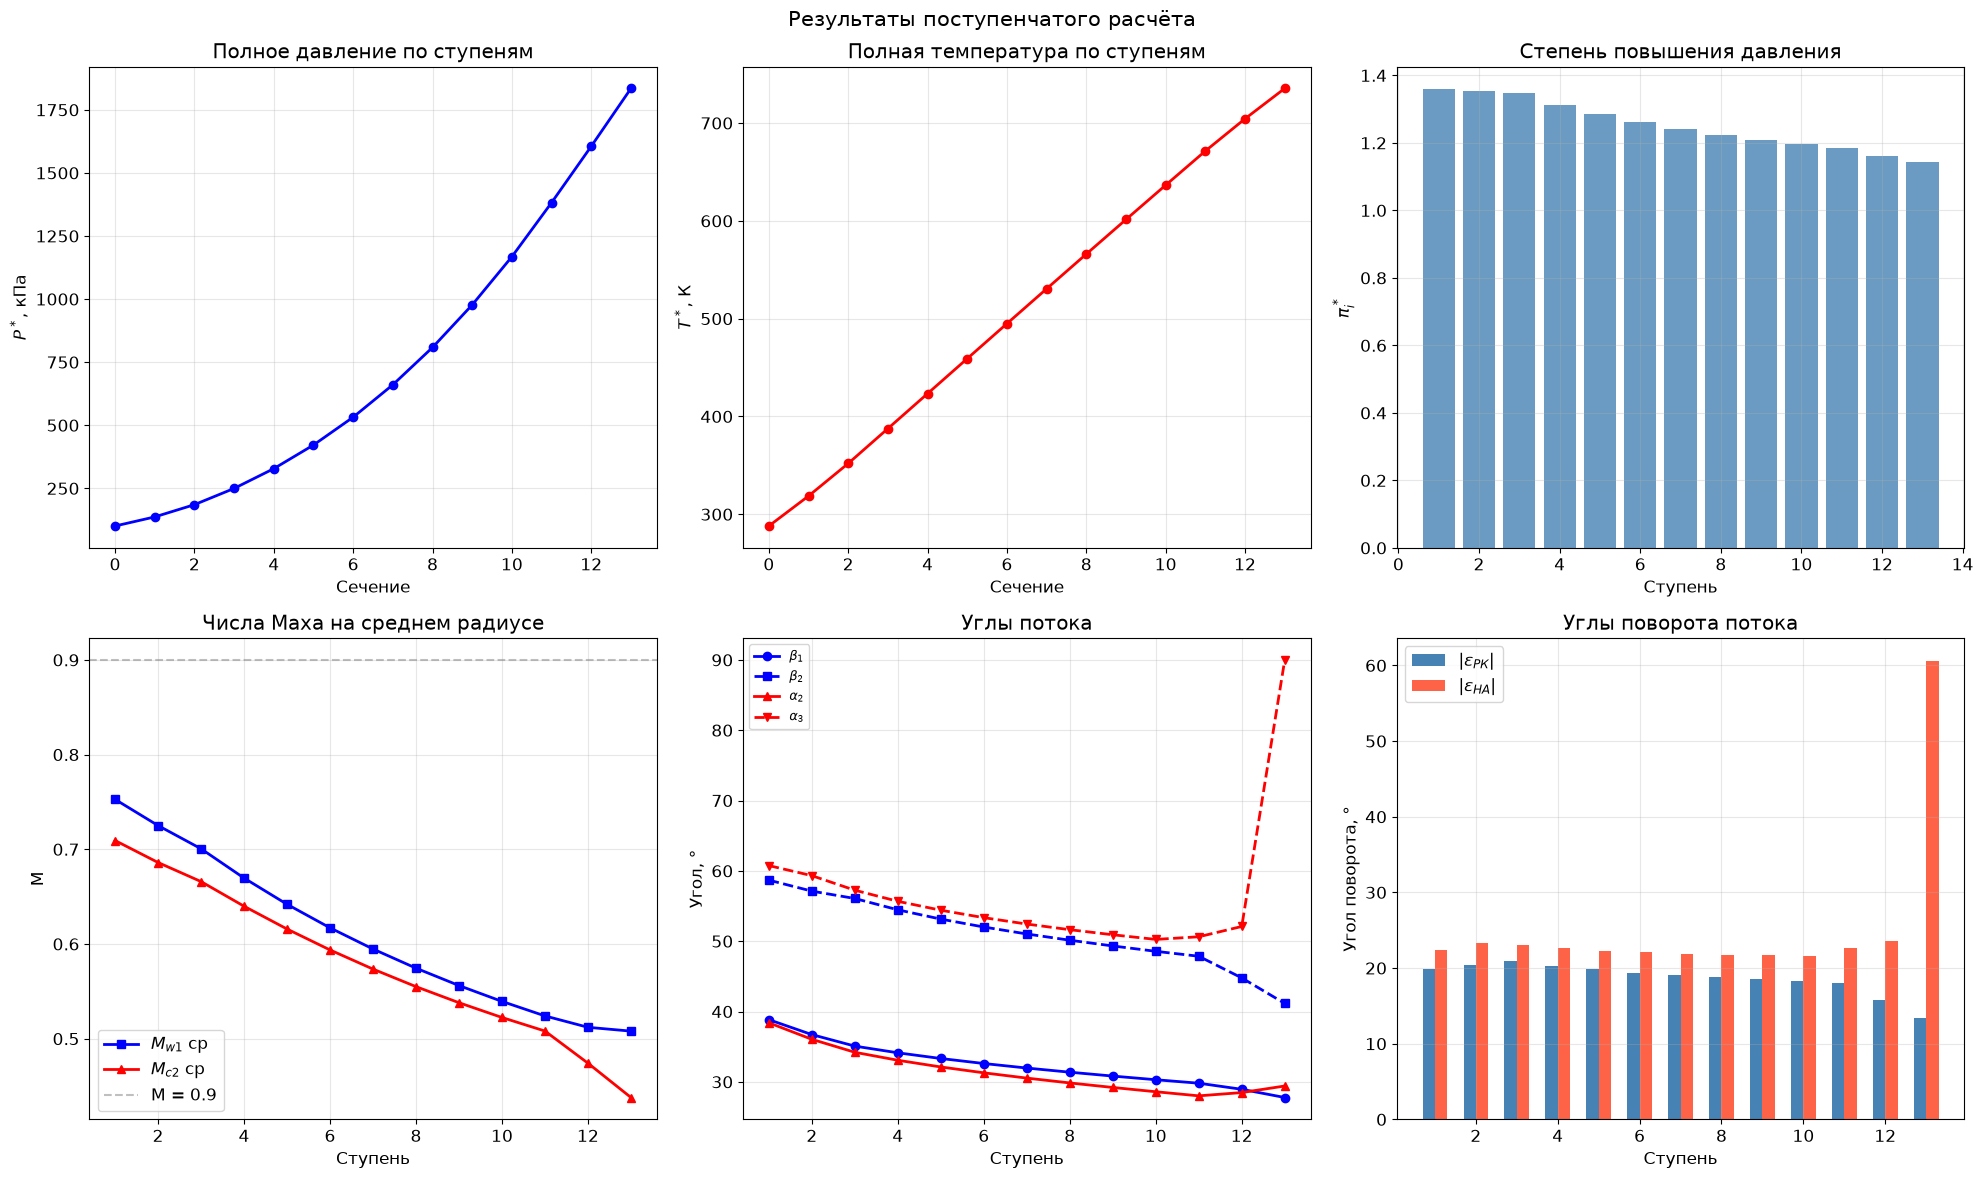

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# P* по ступеням
axes[0,0].plot(range(Z+1), P1s/1000, 'bo-', lw=2, markersize=6)
axes[0,0].set_xlabel('Сечение')
axes[0,0].set_ylabel('$P^*$, кПа')
axes[0,0].set_title('Полное давление по ступеням')

# T* по ступеням
axes[0,1].plot(range(Z+1), T1s, 'ro-', lw=2, markersize=6)
axes[0,1].set_xlabel('Сечение')
axes[0,1].set_ylabel('$T^*$, К')
axes[0,1].set_title('Полная температура по ступеням')

# pi* по ступеням
axes[0,2].bar(stages, pi_st, color='steelblue', alpha=0.8)
axes[0,2].set_xlabel('Ступень')
axes[0,2].set_ylabel('$\\pi^*_i$')
axes[0,2].set_title('Степень повышения давления')

# M_w1 и M_c2
axes[1,0].plot(stages, Mw1_sr, 'bs-', lw=2, label='$M_{w1}$ ср')
axes[1,0].plot(stages, Mc2_sr, 'r^-', lw=2, label='$M_{c2}$ ср')
axes[1,0].axhline(0.9, color='gray', ls='--', alpha=0.5, label='M = 0.9')
axes[1,0].set_xlabel('Ступень')
axes[1,0].set_ylabel('M')
axes[1,0].set_title('Числа Маха на среднем радиусе')
axes[1,0].legend()

# Углы
axes[1,1].plot(stages, np.degrees(beta1), 'b-o', lw=2, label='$\\beta_1$')
axes[1,1].plot(stages, np.degrees(beta2), 'b--s', lw=2, label='$\\beta_2$')
axes[1,1].plot(stages, np.degrees(alpha2), 'r-^', lw=2, label='$\\alpha_2$')
axes[1,1].plot(stages, np.degrees(alpha3), 'r--v', lw=2, label='$\\alpha_3$')
axes[1,1].set_xlabel('Ступень')
axes[1,1].set_ylabel('Угол, °')
axes[1,1].set_title('Углы потока')
axes[1,1].legend(fontsize=9)

# Углы поворота
axes[1,2].bar(stages - 0.15, np.degrees(np.abs(eps_RK)), 0.3, label='$|\\varepsilon_{РК}|$', color='steelblue')
axes[1,2].bar(stages + 0.15, np.degrees(np.abs(eps_NA)), 0.3, label='$|\\varepsilon_{НА}|$', color='tomato')
axes[1,2].set_xlabel('Ступень')
axes[1,2].set_ylabel('Угол поворота, °')
axes[1,2].set_title('Углы поворота потока')
axes[1,2].legend()

plt.suptitle('Результаты поступенчатого расчёта', fontsize=15)
plt.tight_layout()
plt.show()


## 8. Меридиональное сечение проточной части

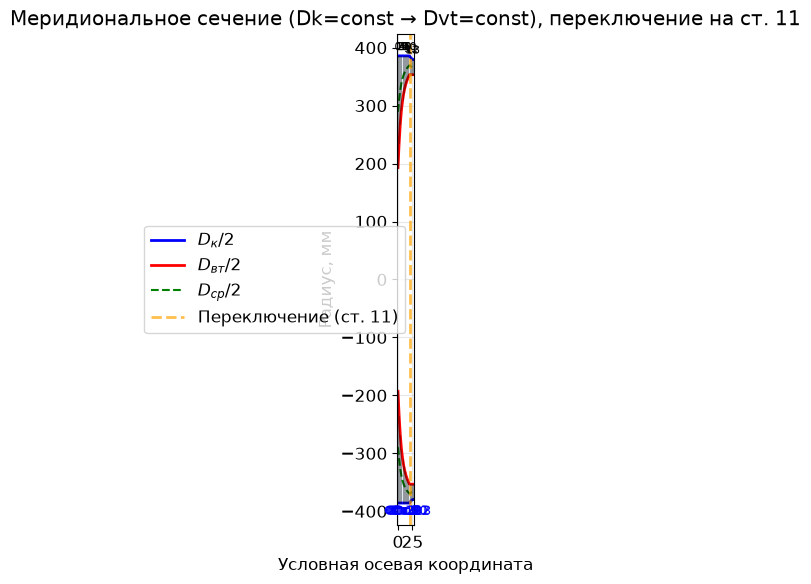

Высота лопатки 1-й ступени:      192.9 мм
Высота лопатки последней ступени: 26.5 мм
Переключение: ступень 11, Dk до = 772 мм, Dvt замор. = 706.6 мм


In [115]:
# Построение меридионального сечения
fig, ax = plt.subplots(1, 1, figsize=(16, 6))

z = np.arange(Z + 1) * 2.0

r_outer = Dk_arr[:Z+1] / 2 * 1000  # мм
r_inner = Dvt_arr[:Z+1] / 2 * 1000  # мм

ax.fill_between(z, r_inner, r_outer, alpha=0.15, color='steelblue')
ax.fill_between(z, -r_inner, -r_outer, alpha=0.15, color='steelblue')

ax.plot(z, r_outer, 'b-', lw=2, label='$D_к/2$')
ax.plot(z, -r_outer, 'b-', lw=2)
ax.plot(z, r_inner, 'r-', lw=2, label='$D_{вт}/2$')
ax.plot(z, -r_inner, 'r-', lw=2)

r_mid = 0.5 * (r_inner + r_outer)
ax.plot(z, r_mid, 'g--', lw=1.5, label='$D_{ср}/2$')
ax.plot(z, -r_mid, 'g--', lw=1.5)

for i in range(Z + 1):
    ax.plot([z[i], z[i]], [r_inner[i], r_outer[i]], 'k-', lw=0.5, alpha=0.5)
    ax.plot([z[i], z[i]], [-r_inner[i], -r_outer[i]], 'k-', lw=0.5, alpha=0.5)
    ax.text(z[i], r_outer[i] + 10, f'{i}', ha='center', fontsize=8)

for i in range(Z):
    ax.text(z[i] + 1.0, -r_outer[0] - 20, f'Ст.{i+1}', ha='center', fontsize=9,
            color='blue')

# Отметка переключения
if i_switch >= 0:
    z_sw = z[i_switch]
    ax.axvline(z_sw, color='orange', ls='--', lw=2, alpha=0.7, label=f'Переключение (ст. {i_switch+1})')

ax.set_xlabel('Условная осевая координата')
ax.set_ylabel('Радиус, мм')
title_str = f'Меридиональное сечение (Dk=const → Dvt=const)'
if i_switch >= 0:
    title_str += f', переключение на ст. {i_switch+1}'
ax.set_title(title_str)
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Высота лопатки 1-й ступени:      {h_blade[0]*1000:.1f} мм")
h_n_final = (Dk_arr[Z] - Dvt_arr[Z]) / 2.0
print(f"Высота лопатки последней ступени: {h_n_final*1000:.1f} мм")
if i_switch >= 0:
    print(f"Переключение: ступень {i_switch+1}, Dk до = {D_k*1000:.0f} мм, Dvt замор. = {D_vt_frozen*1000:.1f} мм")


## 9. Профилирование решёток (п. 4 методики)

Полиномы из оцифрованных графиков:

Рис. 9: $\varepsilon_{b/t=1} = -2.1909 \cdot 10^{-5} \beta_2^3 + 3.7957 \cdot 10^{-3} \beta_2^2 + 0.262104 \beta_2 - 4.49505$

Рис. 10: $\frac{\varepsilon}{\varepsilon_{b/t=1}} = 0.085078 (b/t)^3 - 0.562903 (b/t)^2 + 1.516152 (b/t) - 0.025814$

Угол атаки: $i_0 = i_{0_0} - n_0 \cdot \Theta$

$i_{0_0} = -0.001 \beta_1^2 + 0.580 \beta_1 - 10.791$

$n_0 = -0.210 (b/t)^2 + 1.073 (b/t) + 0.136$


In [116]:
# ================================================
# ПРОФИЛИРОВАНИЕ РЕШЁТОК
# ================================================

def eps_bt1(beta2_deg):
    # Угол поворота при b/t = 1 (рис. 9)
    b = beta2_deg
    return -2.1909e-5 * b**3 + 3.7957e-3 * b**2 + 0.262104 * b - 4.49505

def eps_ratio(bt):
    # eps/eps_{b/t=1} от b/t (рис. 10)
    return 0.085078 * bt**3 - 0.562903 * bt**2 + 1.516152 * bt - 0.025814

def find_bt(eps_required, beta2_deg):
    # Находит b/t для заданного угла поворота eps
    e1 = eps_bt1(beta2_deg)
    if e1 <= 0:
        return 1.0
    ratio = eps_required / e1
    # Решение: eps_ratio(bt) = ratio
    try:
        bt = brentq(lambda x: eps_ratio(x) - ratio, 0.4, 2.5)
    except ValueError:
        bt = 1.0
    return bt

def i00_poly(beta1_deg):
    # i_{0_0} от beta_1 (рис. 12)
    return -0.001 * beta1_deg**2 + 0.580 * beta1_deg - 10.791

def n0_poly(bt):
    # n_0 от b/t (рис. 12)
    return -0.210 * bt**2 + 1.073 * bt + 0.136

# Профилирование для каждой ступени
print(f"{'Ступ':>5} {'beta1':>7} {'beta2':>7} {'eps_РК':>7} {'b/t_РК':>7} "
      f"{'alpha2':>7} {'alpha3':>7} {'eps_НА':>7} {'b/t_НА':>7} "
      f"{'Theta_РК':>9} {'Theta_НА':>9} {'theta_РК':>9} {'theta_НА':>9}")
print("-" * 130)

bt_RK = np.zeros(Z)
bt_NA = np.zeros(Z)
Theta_RK = np.zeros(Z)
Theta_NA = np.zeros(Z)
theta_RK = np.zeros(Z)
theta_NA = np.zeros(Z)
X_f = 0.45  # параболическая средняя линия

for i in range(Z):
    b1_deg = np.degrees(beta1[i])
    b2_deg = np.degrees(beta2[i])
    a2_deg = np.degrees(alpha2[i])
    a3_deg = np.degrees(alpha3[i])

    eps_rk_deg = abs(np.degrees(eps_RK[i]))
    eps_na_deg = abs(np.degrees(eps_NA[i]))

    # b/t для РК
    bt_RK[i] = find_bt(eps_rk_deg, b2_deg) if eps_rk_deg > 0 else 1.0
    # b/t для НА
    bt_NA[i] = find_bt(eps_na_deg, a3_deg) if eps_na_deg > 0 else 1.0

    # Углы атаки (номинальный режим)
    i_RK = 2.5 * (bt_RK[i] - 1.0)
    i_NA = 2.5 * (bt_NA[i] - 2.0)

    # Коэффициент m для угла отставания
    m_RK = 0.23 * (2*X_f)**2 + 0.18 - 0.002 * b2_deg
    m_NA = 0.23 * (2*X_f)**2 + 0.18 - 0.002 * a3_deg

    # Угол изгиба Theta: Theta = (eps - i + delta), delta = m*Theta*sqrt(t/b)
    # => Theta * (1 - m*sqrt(t/b)) = eps - i
    # => Theta = (eps - i) / (1 - m/sqrt(b/t))
    denom_rk = 1.0 - m_RK / np.sqrt(bt_RK[i]) if bt_RK[i] > 0 else 1.0
    Theta_RK[i] = (eps_rk_deg - i_RK) / denom_rk if abs(denom_rk) > 0.01 else eps_rk_deg

    denom_na = 1.0 - m_NA / np.sqrt(bt_NA[i]) if bt_NA[i] > 0 else 1.0
    Theta_NA[i] = (eps_na_deg - i_NA) / denom_na if abs(denom_na) > 0.01 else eps_na_deg

    # Угол установки
    chi1 = 0.6  # для X_f = 0.45
    theta_RK[i] = chi1 * Theta_RK[i] + b1_deg + i_RK
    theta_NA[i] = chi1 * Theta_NA[i] + a2_deg + i_NA

    print(f"{i+1:>5d} {b1_deg:>7.1f} {b2_deg:>7.1f} {eps_rk_deg:>7.1f} {bt_RK[i]:>7.3f} "
          f"{a2_deg:>7.1f} {a3_deg:>7.1f} {eps_na_deg:>7.1f} {bt_NA[i]:>7.3f} "
          f"{Theta_RK[i]:>9.1f} {Theta_NA[i]:>9.1f} {theta_RK[i]:>9.1f} {theta_NA[i]:>9.1f}")


 Ступ   beta1   beta2  eps_РК  b/t_РК  alpha2  alpha3  eps_НА  b/t_НА  Theta_РК  Theta_НА  theta_РК  theta_НА
----------------------------------------------------------------------------------------------------------------------------------
    1    38.8    58.7    19.8   1.005    38.4    60.8    22.4   1.126      26.4      31.9      54.7      55.4
    2    36.7    57.1    20.4   1.121    36.0    59.3    23.3   1.284      26.4      32.1      52.8      53.5
    3    35.1    56.1    21.0   1.236    34.2    57.3    23.0   1.392      26.4      31.2      51.5      51.4
    4    34.1    54.5    20.3   1.262    33.1    55.7    22.6   1.454      25.5      30.4      50.1      49.9
    5    33.3    53.1    19.8   1.289    32.1    54.4    22.3   1.517      24.8      29.7      48.9      48.7
    6    32.6    52.0    19.4   1.317    31.3    53.3    22.1   1.582      24.1      29.1      47.9      47.7
    7    32.0    51.0    19.1   1.346    30.5    52.4    21.9   1.650      23.6      28.6      47.0

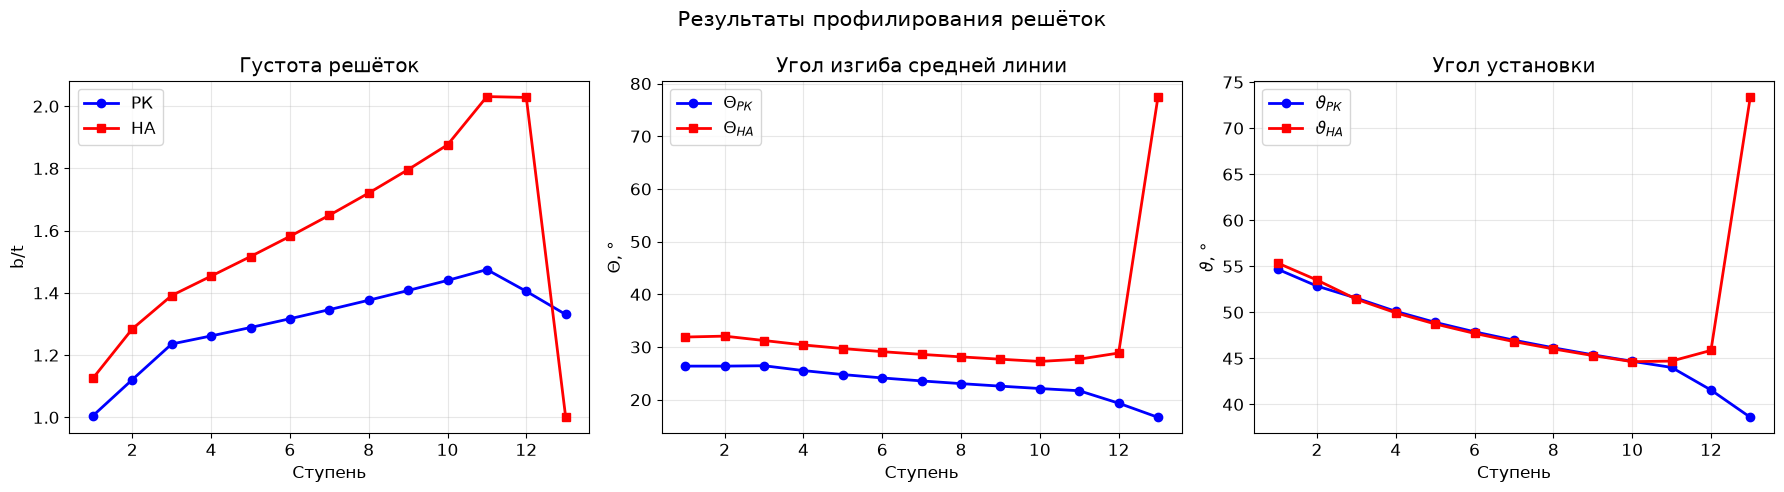

In [117]:
# Построение густоты и углов по ступеням
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(stages, bt_RK, 'bo-', lw=2, label='РК')
axes[0].plot(stages, bt_NA, 'rs-', lw=2, label='НА')
axes[0].set_xlabel('Ступень')
axes[0].set_ylabel('b/t')
axes[0].set_title('Густота решёток')
axes[0].legend()

axes[1].plot(stages, Theta_RK, 'bo-', lw=2, label='$\\Theta_{РК}$')
axes[1].plot(stages, Theta_NA, 'rs-', lw=2, label='$\\Theta_{НА}$')
axes[1].set_xlabel('Ступень')
axes[1].set_ylabel('$\\Theta$, °')
axes[1].set_title('Угол изгиба средней линии')
axes[1].legend()

axes[2].plot(stages, theta_RK, 'bo-', lw=2, label='$\\vartheta_{РК}$')
axes[2].plot(stages, theta_NA, 'rs-', lw=2, label='$\\vartheta_{НА}$')
axes[2].set_xlabel('Ступень')
axes[2].set_ylabel('$\\vartheta$, °')
axes[2].set_title('Угол установки')
axes[2].legend()

plt.suptitle('Результаты профилирования решёток', fontsize=15)
plt.tight_layout()
plt.show()


## 10. Треугольники скоростей (все ступени, R=const по высоте)

По методике из `Math_triang.md` — пересчёт скоростей с среднего радиуса на втулку и периферию при законе $R_{ср} = \text{const}$:

$$c_{a,\text{лок}} = \sqrt{c_{a,\text{ср}}^2 - 2(1-R)^2 (u_\text{лок}^2 - u_\text{ср3}^2)}$$

$$c_{u,\text{лок}} = u_\text{лок}(1-R) \mp \frac{H_T}{2 u_\text{лок}}$$

Три сечения: **1** — вход в РК, **2** — выход из РК, **3** — выход из НА.

Три радиуса: **втулка** (вт), **среднее** (ср), **периферия** (к).

In [118]:
# ================================================
# ТРЕУГОЛЬНИКИ СКОРОСТЕЙ — R=const по высоте
# Все ступени, втулка / среднее / периферия
# ================================================

omega = 2.0 * np.pi * n_rpm / 60.0  # угловая скорость вращения

# Результаты: [Z, 3] — 3 радиуса: 0=вт, 1=ср, 2=к
# Сечение 1 (вход в РК)
c1a_r  = np.zeros((Z, 3));  c1u_r  = np.zeros((Z, 3))
al1_r  = np.zeros((Z, 3));  c1_r   = np.zeros((Z, 3))
w1a_r  = np.zeros((Z, 3));  w1u_r  = np.zeros((Z, 3))
bt1_r  = np.zeros((Z, 3));  w1_r   = np.zeros((Z, 3))

# Сечение 2 (выход из РК)
c2a_r  = np.zeros((Z, 3));  c2u_r  = np.zeros((Z, 3))
al2_r  = np.zeros((Z, 3));  c2_r   = np.zeros((Z, 3))
w2a_r  = np.zeros((Z, 3));  w2u_r  = np.zeros((Z, 3))
bt2_r  = np.zeros((Z, 3));  w2_r   = np.zeros((Z, 3))

# Сечение 3 (выход из НА)
c3a_r  = np.zeros((Z, 3));  c3u_r  = np.zeros((Z, 3))
al3_r  = np.zeros((Z, 3));  c3_r   = np.zeros((Z, 3))

# Окружные скорости на каждом сечении
u1_r = np.zeros((Z, 3))
u2_r = np.zeros((Z, 3))
u3_r = np.zeros((Z, 3))

for i in range(Z):
    # --- Диаметры ---
    Dk1  = Dk_arr[i];    Dvt1  = Dvt_arr[i]
    Dk3  = Dk_arr[i+1];  Dvt3  = Dvt_arr[i+1]
    Dk2  = 0.5*(Dk1 + Dk3);  Dvt2 = 0.5*(Dvt1 + Dvt3)

    Dsr1 = np.sqrt((Dk1**2 + Dvt1**2) / 2.0)
    Dsr2 = np.sqrt((Dk2**2 + Dvt2**2) / 2.0)
    Dsr3 = np.sqrt((Dk3**2 + Dvt3**2) / 2.0)

    # --- Окружные скорости ---
    u_vt1 = omega * Dvt1/2;  u_sr1 = omega * Dsr1/2;  u_k1 = omega * Dk1/2
    u_vt2 = omega * Dvt2/2;  u_sr2 = omega * Dsr2/2;  u_k2 = omega * Dk2/2
    u_vt3 = omega * Dvt3/2;  u_sr3 = omega * Dsr3/2;  u_k3 = omega * Dk3/2

    u1_r[i] = [u_vt1, u_sr1, u_k1]
    u2_r[i] = [u_vt2, u_sr2, u_k2]
    u3_r[i] = [u_vt3, u_sr3, u_k3]

    u_ref = u_sr3  # опорная скорость для закона R=const

    # --- Базовые осевые скорости (на среднем радиусе) ---
    c1a_base = ca1_dim[i]
    c2a_base = ca2_dim[i]
    c3a_base = ca1_dim[i+1] if i < Z - 1 else ca2_dim[i]

    HT = HT_dim[i]
    R  = R_dist[i]

    # Среднее сечение: u_ref = u_ср3 для всех формул (закон R=const)
    # Втулка и периферия: локальные u каждого сечения
    u_s1 = [u_vt1, u_ref, u_k1]
    u_s2 = [u_vt2, u_ref, u_k2]
    u_s3 = [u_vt3, u_ref, u_k3]

    for j in range(3):  # 0=вт, 1=ср, 2=к
        uu1, uu2, uu3 = u_s1[j], u_s2[j], u_s3[j]

        # ---- Сечение 1 (вход в РК) ----
        c1a_sq = c1a_base**2 - 2.0*(1.0 - R)**2 * (uu1**2 - u_ref**2)
        c1a_r[i,j] = np.sqrt(max(c1a_sq, 1.0))
        c1u_r[i,j] = uu1*(1.0 - R) - HT / (2.0*uu1)
        al1_r[i,j] = np.arctan2(c1a_r[i,j], c1u_r[i,j])
        c1_r[i,j]  = c1a_r[i,j] / max(np.sin(al1_r[i,j]), 0.01)
        w1a_r[i,j] = c1a_r[i,j]
        w1u_r[i,j] = uu1 - c1u_r[i,j]
        bt1_r[i,j] = np.arctan2(w1a_r[i,j], w1u_r[i,j])
        w1_r[i,j]  = w1a_r[i,j] / max(np.sin(bt1_r[i,j]), 0.01)

        # ---- Сечение 2 (выход из РК) ----
        c2a_sq = c2a_base**2 - 2.0*(1.0 - R)**2 * (uu2**2 - u_ref**2)
        c2a_r[i,j] = np.sqrt(max(c2a_sq, 1.0))
        c2u_r[i,j] = uu2*(1.0 - R) + HT / (2.0*uu2)  # + для выхода из РК
        al2_r[i,j] = np.arctan2(c2a_r[i,j], c2u_r[i,j])
        c2_r[i,j]  = c2a_r[i,j] / max(np.sin(al2_r[i,j]), 0.01)
        w2a_r[i,j] = c2a_r[i,j]
        w2u_r[i,j] = uu2 - c2u_r[i,j]
        bt2_r[i,j] = np.arctan2(w2a_r[i,j], w2u_r[i,j])
        w2_r[i,j]  = w2a_r[i,j] / max(np.sin(bt2_r[i,j]), 0.01)

        # ---- Сечение 3 (выход из НА) ----
        c3a_sq = c3a_base**2 - 2.0*(1.0 - R)**2 * (uu3**2 - u_ref**2)
        c3a_r[i,j] = np.sqrt(max(c3a_sq, 1.0))
        c3u_r[i,j] = uu3*(1.0 - R) - HT / (2.0*uu3)
        al3_r[i,j] = np.arctan2(c3a_r[i,j], c3u_r[i,j])
        c3_r[i,j]  = c3a_r[i,j] / max(np.sin(al3_r[i,j]), 0.01)

# =============================================
# Таблица для 1-й ступени (по формату Math_triang.md)
# =============================================
i0 = 0

print("=" * 72)
print(f"ТРЕУГОЛЬНИКИ СКОРОСТЕЙ — СТУПЕНЬ {i0+1}")
print("=" * 72)

print(f"\n--- Вход в РК (сечение 1) ---")
print(f"{'Параметр':<16} {'Периферия':>12} {'Среднее':>12} {'Втулка':>12}")
print("-" * 52)
for name, arr in [
    ("c_1a, м/с",   c1a_r[i0]),
    ("c_1u, м/с",   c1u_r[i0]),
    ("α_1, °",      np.degrees(al1_r[i0])),
    ("β_1, °",      np.degrees(bt1_r[i0])),
    ("c_1, м/с",    c1_r[i0]),
    ("w_1a, м/с",   w1a_r[i0]),
    ("w_1u, м/с",   w1u_r[i0]),
    ("w_1, м/с",    w1_r[i0]),
    ("u_1, м/с",    u1_r[i0]),
]:
    print(f"{name:<16} {arr[2]:>12.1f} {arr[1]:>12.1f} {arr[0]:>12.1f}")

print(f"\n--- Выход из РК (сечение 2) ---")
print(f"{'Параметр':<16} {'Периферия':>12} {'Среднее':>12} {'Втулка':>12}")
print("-" * 52)
for name, arr in [
    ("c_2a, м/с",   c2a_r[i0]),
    ("c_2u, м/с",   c2u_r[i0]),
    ("α_2, °",      np.degrees(al2_r[i0])),
    ("β_2, °",      np.degrees(bt2_r[i0])),
    ("c_2, м/с",    c2_r[i0]),
    ("w_2a, м/с",   w2a_r[i0]),
    ("w_2u, м/с",   w2u_r[i0]),
    ("w_2, м/с",    w2_r[i0]),
    ("u_2, м/с",    u2_r[i0]),
]:
    print(f"{name:<16} {arr[2]:>12.1f} {arr[1]:>12.1f} {arr[0]:>12.1f}")

print(f"\n--- Выход из НА (сечение 3) ---")
print(f"{'Параметр':<16} {'Периферия':>12} {'Среднее':>12} {'Втулка':>12}")
print("-" * 52)
for name, arr in [
    ("c_3a, м/с",   c3a_r[i0]),
    ("c_3u, м/с",   c3u_r[i0]),
    ("α_3, °",      np.degrees(al3_r[i0])),
    ("c_3, м/с",    c3_r[i0]),
    ("u_3, м/с",    u3_r[i0]),
]:
    print(f"{name:<16} {arr[2]:>12.1f} {arr[1]:>12.1f} {arr[0]:>12.1f}")

# =============================================
# Компактная таблица для всех ступеней (углы)
# =============================================
print("\n" + "=" * 100)
print("УГЛЫ ПО СТУПЕНЯМ (периферия / среднее / втулка)")
print("=" * 100)

def row3(label, arr, fmt=".1f"):
    s = f"{label:<14}"
    for i in range(Z):
        v = arr[i]
        s += f" {v[2]:>5{fmt}}/{v[1]:>5{fmt}}/{v[0]:>5{fmt}}"
    print(s)

hdr = f"{'Параметр':<14}"
for i in range(Z):
    hdr += f"  {'Ст.'+str(i+1):^17}"
print(hdr)

row3("α_1, °", np.degrees(al1_r))
row3("β_1, °", np.degrees(bt1_r))
row3("α_2, °", np.degrees(al2_r))
row3("β_2, °", np.degrees(bt2_r))
row3("α_3, °", np.degrees(al3_r))

# =============================================
# Графики треугольников скоростей (1-я ступень)
# Три отдельных графика (по одному на радиус)
# =============================================
radius_labels = ['Периферия (к)', 'Среднее (ср)', 'Втулка (вт)']
radius_idx    = [2, 1, 0]

for rlabel, ri in zip(radius_labels, radius_idx):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Вход в РК ---
    ax = axes[0]
    ca1 = c1a_r[i0, ri];  cu1 = c1u_r[i0, ri];  u_loc = u1_r[i0, ri]
    ax.annotate('', xy=(cu1, ca1), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.text(cu1*0.4, ca1*0.55, '$c_1$', color='blue', fontsize=12, fontweight='bold')
    ax.annotate('', xy=(u_loc, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax.text(u_loc*0.5, -10, '$u$', color='green', fontsize=12, fontweight='bold')
    ax.annotate('', xy=(cu1, ca1), xytext=(u_loc, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text((cu1+u_loc)*0.5 - 15, ca1*0.5, '$w_1$', color='red', fontsize=12, fontweight='bold')
    ax.set_title(f'{rlabel} — вход в РК', fontsize=11)
    ax.set_xlabel('$c_u$, м/с');  ax.set_ylabel('$c_a$, м/с')
    ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5)

    # --- Выход из РК ---
    ax = axes[1]
    ca2 = c2a_r[i0, ri];  cu2 = c2u_r[i0, ri];  u_loc2 = u2_r[i0, ri]
    ax.annotate('', xy=(cu2, ca2), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.text(cu2*0.4, ca2*0.55, '$c_2$', color='blue', fontsize=12, fontweight='bold')
    ax.annotate('', xy=(u_loc2, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
    ax.text(u_loc2*0.5, -10, '$u$', color='green', fontsize=12, fontweight='bold')
    ax.annotate('', xy=(cu2, ca2), xytext=(u_loc2, 0),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.text((cu2+u_loc2)*0.5 + 5, ca2*0.5, '$w_2$', color='red', fontsize=12, fontweight='bold')
    ax.set_title(f'{rlabel} — выход из РК', fontsize=11)
    ax.set_xlabel('$c_u$, м/с');  ax.set_ylabel('$c_a$, м/с')
    ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5)

    fig.suptitle(f'Ступень {i0+1} — {rlabel}', fontsize=13)
    plt.tight_layout()
    plt.show()

ТРЕУГОЛЬНИКИ СКОРОСТЕЙ — СТУПЕНЬ 1

--- Вход в РК (сечение 1) ---
Параметр            Периферия      Среднее       Втулка
----------------------------------------------------
c_1a, м/с                74.5        156.3        225.4
c_1u, м/с               128.8         89.8         -3.0
α_1, °                   30.1         60.1         90.8
β_1, °                   18.8         38.3         51.9
c_1, м/с                148.8        180.3        225.5
w_1a, м/с                74.5        156.3        225.4
w_1u, м/с               218.6        198.2        176.7
w_1, м/с                231.0        252.4        286.4
u_1, м/с                347.4        274.7        173.7

--- Выход из РК (сечение 2) ---
Параметр            Периферия      Среднее       Втулка
----------------------------------------------------
c_2a, м/с                61.0        150.3        213.1
c_2u, м/с               218.6        198.2        177.3
α_2, °                   15.6         37.2         50.2
β_2, °     

MemoryError: std::bad_alloc

<Figure size 1200x400 with 2 Axes>

MemoryError: std::bad_alloc

<Figure size 1200x400 with 2 Axes>

MemoryError: std::bad_alloc

<Figure size 1200x400 with 2 Axes>

## 11. Профиль А-40 (табл. 4 методики)

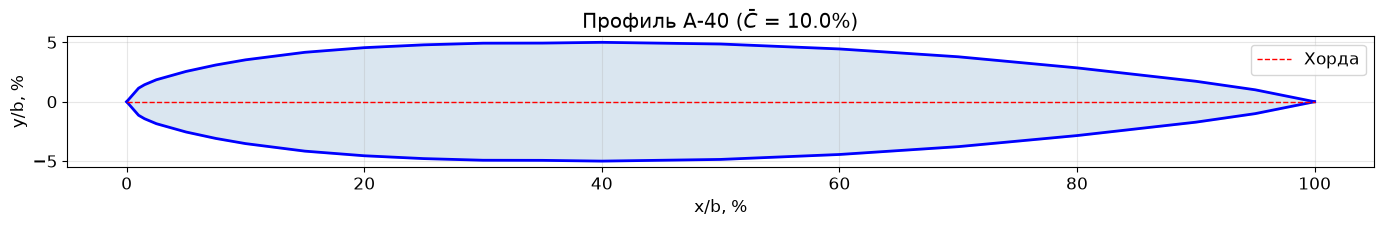

In [119]:
# Координаты профиля А-40 (симметричный)
xb_pct = np.array([0, 1.0, 1.5, 2.5, 5.0, 7.5, 10, 15, 20, 25, 30, 35,
                    40, 50, 60, 70, 80, 90, 95, 100])
yb_pct = np.array([0, 1.14, 1.43, 1.85, 2.55, 3.09, 3.525, 4.16, 4.55, 4.788,
                    4.927, 4.936, 5.00, 4.858, 4.442, 3.783, 2.85, 1.722, 1.003, 0])

# Относительная толщина C_bar = 10% (по умолчанию)
C_bar = 10.0  # %

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.fill_between(xb_pct, yb_pct * C_bar / 10, -yb_pct * C_bar / 10, alpha=0.2, color='steelblue')
ax.plot(xb_pct, yb_pct * C_bar / 10, 'b-', lw=2)
ax.plot(xb_pct, -yb_pct * C_bar / 10, 'b-', lw=2)
ax.plot(xb_pct, np.zeros_like(xb_pct), 'r--', lw=1, label='Хорда')
ax.set_xlabel('x/b, %')
ax.set_ylabel('y/b, %')
ax.set_title(f'Профиль А-40 ($\\bar{{C}}$ = {C_bar}%)')
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11.5 Профилирование лопаток по трём сечениям (по metoda_lopatki.md)

Расчёт профилирования решёток РК и НА на **периферии**, **среднем** и **втулочном** сечениях:
- Хорды и число лопаток
- Шаги и густоты на каждом сечении
- Углы атаки, изгиба, отставания, установки
- Радиусы дуг средних линий
- Коэффициенты диффузорности (D-фактор Либляйна)
- Построение профилей А-40 для 1-й ступени (6 сечений)

In [120]:
# ================================================
# ПРОФИЛИРОВАНИЕ ЛОПАТОК ПО ТРЁМ СЕЧЕНИЯМ
# (по metoda_lopatki.md)
# ================================================

# --- Хорды лопаток ---
AR_RK_first = 1.6
AR_NA_first = 2.0
AR_RK_last = 1.0
AR_NA_last = 1.3

AR_RK_arr = np.linspace(AR_RK_first, AR_RK_last, Z)
AR_NA_arr = np.linspace(AR_NA_first, AR_NA_last, Z)

b_RK = h_blade / AR_RK_arr
b_NA = h_blade / AR_NA_arr

# --- Диаметры на входе/выходе каждого венца ---
Dk1_prof  = Dk_arr[:Z]
Dvt1_prof = Dvt_arr[:Z]
Dsr1_prof = np.sqrt((Dk1_prof**2 + Dvt1_prof**2) / 2.0)

Dk3_prof  = Dk_arr[1:Z+1]
Dvt3_prof = Dvt_arr[1:Z+1]

Dk2_prof  = 0.5 * (Dk1_prof + Dk3_prof)
Dvt2_prof = 0.5 * (Dvt1_prof + Dvt3_prof)
Dsr2_prof = np.sqrt((Dk2_prof**2 + Dvt2_prof**2) / 2.0)

# --- Число лопаток ---
t_RK_sr = b_RK / bt_RK
t_NA_sr = b_NA / bt_NA
Z_RK_blades = np.maximum(np.round(np.pi * Dsr1_prof / t_RK_sr).astype(int), 10)
Z_NA_blades = np.maximum(np.round(np.pi * Dsr2_prof / t_NA_sr).astype(int), 10)

# --- Шаги на трёх сечениях ---
t_RK_k  = np.pi * Dk1_prof  / Z_RK_blades
t_RK_sr_a = np.pi * Dsr1_prof / Z_RK_blades
t_RK_vt = np.pi * Dvt1_prof / Z_RK_blades

t_NA_k  = np.pi * Dk2_prof  / Z_NA_blades
t_NA_sr_a = np.pi * Dsr2_prof / Z_NA_blades
t_NA_vt = np.pi * Dvt2_prof / Z_NA_blades

# --- Густоты на трёх сечениях ---
# По методике: хорда РК на периферии 1.2*b, на втулке 0.9*b
#              хорда НА на периферии 0.9*b, на втулке 1.2*b
bt_RK_k_arr  = (1.2 * b_RK) / t_RK_k
bt_RK_sr_arr = b_RK / t_RK_sr_a
bt_RK_vt_arr = (0.9 * b_RK) / t_RK_vt

bt_NA_k_arr  = (0.9 * b_NA) / t_NA_k
bt_NA_sr_arr = b_NA / t_NA_sr_a
bt_NA_vt_arr = (1.2 * b_NA) / t_NA_vt

# --- Углы из треугольников скоростей (cell 30) ---
# bt1_r[i,j], bt2_r[i,j], al2_r[i,j], al3_r[i,j] — j: 0=вт, 1=ср, 2=к
beta1_3s  = np.degrees(bt1_r)   # [Z, 3]
beta2_3s  = np.degrees(bt2_r)
alpha2_3s = np.degrees(al2_r)
alpha3_3s = np.degrees(al3_r)

eps_RK_3s = beta2_3s - beta1_3s
eps_NA_3s = alpha3_3s - alpha2_3s

# --- Массивы густот по сечениям: [Z, 3] — 0=вт, 1=ср, 2=к ---
bt_RK_3s = np.column_stack([bt_RK_vt_arr, bt_RK_sr_arr, bt_RK_k_arr])
bt_NA_3s = np.column_stack([bt_NA_vt_arr, bt_NA_sr_arr, bt_NA_k_arr])

b_RK_chord_3s = np.column_stack([0.9*b_RK, b_RK, 1.2*b_RK])
b_NA_chord_3s = np.column_stack([1.2*b_NA, b_NA, 0.9*b_NA])

# --- Профилирование: углы атаки, изгиба, отставания, установки ---
X_f = 0.5  # дуга окружности

i_RK_3s  = np.zeros((Z, 3))
i_NA_3s  = np.zeros((Z, 3))
m_RK_3s  = np.zeros((Z, 3))
m_NA_3s  = np.zeros((Z, 3))
theta_RK_3s = np.zeros((Z, 3))
theta_NA_3s = np.zeros((Z, 3))
delta_RK_3s = np.zeros((Z, 3))
delta_NA_3s = np.zeros((Z, 3))
ups_RK_3s = np.zeros((Z, 3))
ups_NA_3s = np.zeros((Z, 3))
Rsl_RK_3s = np.zeros((Z, 3))
Rsl_NA_3s = np.zeros((Z, 3))

for i in range(Z):
    for j in range(3):
        # РК
        i_RK_3s[i,j] = 2.5 * (bt_RK_3s[i,j] - 1.0)
        m_RK_3s[i,j] = 0.23 * (2*X_f)**2 + 0.18 - 0.002 * beta2_3s[i,j]
        eps_abs = abs(eps_RK_3s[i,j])
        denom = 1.0 - m_RK_3s[i,j] * np.sqrt(1.0/bt_RK_3s[i,j]) if bt_RK_3s[i,j] > 0.01 else 1.0
        theta_RK_3s[i,j] = (eps_abs - i_RK_3s[i,j]) / denom if abs(denom) > 0.01 else eps_abs
        delta_RK_3s[i,j] = m_RK_3s[i,j] * theta_RK_3s[i,j] * np.sqrt(1.0/bt_RK_3s[i,j]) if bt_RK_3s[i,j] > 0.01 else 0
        ups_RK_3s[i,j] = 0.5 * theta_RK_3s[i,j] + beta1_3s[i,j] + i_RK_3s[i,j]
        sh = np.sin(np.radians(theta_RK_3s[i,j] / 2.0))
        Rsl_RK_3s[i,j] = b_RK_chord_3s[i,j] / (2.0 * sh) if abs(sh) > 0.001 else 0

        # НА
        i_NA_3s[i,j] = 2.5 * (bt_NA_3s[i,j] - 2.0)
        m_NA_3s[i,j] = 0.23 * (2*X_f)**2 + 0.18 - 0.002 * alpha3_3s[i,j]
        eps_abs_na = abs(eps_NA_3s[i,j])
        denom_na = 1.0 - m_NA_3s[i,j] * np.sqrt(1.0/bt_NA_3s[i,j]) if bt_NA_3s[i,j] > 0.01 else 1.0
        theta_NA_3s[i,j] = (eps_abs_na - i_NA_3s[i,j]) / denom_na if abs(denom_na) > 0.01 else eps_abs_na
        delta_NA_3s[i,j] = m_NA_3s[i,j] * theta_NA_3s[i,j] * np.sqrt(1.0/bt_NA_3s[i,j]) if bt_NA_3s[i,j] > 0.01 else 0
        ups_NA_3s[i,j] = 0.5 * theta_NA_3s[i,j] + alpha2_3s[i,j] + i_NA_3s[i,j]
        sh_na = np.sin(np.radians(theta_NA_3s[i,j] / 2.0))
        Rsl_NA_3s[i,j] = b_NA_chord_3s[i,j] / (2.0 * sh_na) if abs(sh_na) > 0.001 else 0

# --- Коэффициенты диффузорности (D-фактор Либляйна) ---
D_RK_3s = np.zeros((Z, 3))
D_NA_3s = np.zeros((Z, 3))

for i in range(Z):
    for j in range(3):
        b1r = np.radians(beta1_3s[i,j])
        b2r = np.radians(beta2_3s[i,j])
        K_rk = c2a_r[i,j] / c1a_r[i,j] if c1a_r[i,j] > 1 else 1.0
        D_RK_3s[i,j] = (1.0 - K_rk * np.sin(b1r) / np.sin(b2r)) + \
            (1.0/np.tan(b1r) - K_rk/np.tan(b2r)) * np.sin(b1r) / (2.0 * bt_RK_3s[i,j])

        a2r = np.radians(alpha2_3s[i,j])
        a3r = np.radians(alpha3_3s[i,j])
        K_na = c3a_r[i,j] / c2a_r[i,j] if c2a_r[i,j] > 1 else 1.0
        D_NA_3s[i,j] = (1.0 - K_na * np.sin(a2r) / np.sin(a3r)) + \
            (1.0/np.tan(a2r) - K_na/np.tan(a3r)) * np.sin(a2r) / (2.0 * bt_NA_3s[i,j])

# ================================================
# ТАБЛИЦЫ РЕЗУЛЬТАТОВ
# ================================================
sec_names = ['Периферия', 'Среднее', 'Втулка']
sec_idx   = [2, 1, 0]

print("=" * 120)
print("ХОРДЫ, ЧИСЛО ЛОПАТОК, ШАГИ")
print("=" * 120)
print(f"{'Ступ':>5} {'b_РК,мм':>8} {'Z_РК':>5} {'b_НА,мм':>8} {'Z_НА':>5} "
      f"{'t_РК.к':>7} {'t_РК.ср':>7} {'t_РК.вт':>7} "
      f"{'t_НА.к':>7} {'t_НА.ср':>7} {'t_НА.вт':>7}")
for i in range(Z):
    print(f"{i+1:>5d} {b_RK[i]*1000:>8.1f} {Z_RK_blades[i]:>5d} "
          f"{b_NA[i]*1000:>8.1f} {Z_NA_blades[i]:>5d} "
          f"{t_RK_k[i]*1000:>7.1f} {t_RK_sr_a[i]*1000:>7.1f} {t_RK_vt[i]*1000:>7.1f} "
          f"{t_NA_k[i]*1000:>7.1f} {t_NA_sr_a[i]*1000:>7.1f} {t_NA_vt[i]*1000:>7.1f}")

for si, sn in zip(sec_idx, sec_names):
    print(f"\n{'=' * 120}")
    print(f"ПРОФИЛИРОВАНИЕ — {sn} сечение")
    print(f"{'=' * 120}")
    print(f"{'Ступ':>5} {'b/t_РК':>7} {'i_РК':>7} {'θ_РК':>7} {'δ_РК':>7} {'υ_РК':>7} {'R_сл_РК':>8} "
          f"{'b/t_НА':>7} {'i_НА':>7} {'θ_НА':>7} {'δ_НА':>7} {'υ_НА':>7} {'R_сл_НА':>8} "
          f"{'D_РК':>6} {'D_НА':>6}")
    print("-" * 120)
    for i in range(Z):
        print(f"{i+1:>5d} "
              f"{bt_RK_3s[i,si]:>7.3f} {i_RK_3s[i,si]:>7.2f} {theta_RK_3s[i,si]:>7.1f} "
              f"{delta_RK_3s[i,si]:>7.2f} {ups_RK_3s[i,si]:>7.1f} {Rsl_RK_3s[i,si]:>8.4f} "
              f"{bt_NA_3s[i,si]:>7.3f} {i_NA_3s[i,si]:>7.2f} {theta_NA_3s[i,si]:>7.1f} "
              f"{delta_NA_3s[i,si]:>7.2f} {ups_NA_3s[i,si]:>7.1f} {Rsl_NA_3s[i,si]:>8.4f} "
              f"{D_RK_3s[i,si]:>6.3f} {D_NA_3s[i,si]:>6.3f}")

# Сводная таблица углов изгиба
print(f"\n{'=' * 100}")
print("СВОДКА УГЛОВ ИЗГИБА θ (°)")
print(f"{'=' * 100}")
print(f"{'Ступ':>5}  {'θ_РК.к':>8} {'θ_РК.ср':>8} {'θ_РК.вт':>8}  {'θ_НА.к':>8} {'θ_НА.ср':>8} {'θ_НА.вт':>8}")
for i in range(Z):
    print(f"{i+1:>5d}  {theta_RK_3s[i,2]:>8.1f} {theta_RK_3s[i,1]:>8.1f} {theta_RK_3s[i,0]:>8.1f}  "
          f"{theta_NA_3s[i,2]:>8.1f} {theta_NA_3s[i,1]:>8.1f} {theta_NA_3s[i,0]:>8.1f}")


ХОРДЫ, ЧИСЛО ЛОПАТОК, ШАГИ
 Ступ  b_РК,мм  Z_РК  b_НА,мм  Z_НА  t_РК.к t_РК.ср t_РК.вт  t_НА.к t_НА.ср t_НА.вт
    1    120.6    16     96.4    23   151.5   119.8    75.7   105.4    85.3    58.6
    2     96.6    23     77.1    34   105.4    87.4    64.5    71.3    60.2    46.6
    3     78.0    33     62.1    47    73.5    63.3    51.2    51.6    45.1    37.5
    4     64.3    42     51.1    62    57.7    51.2    43.8    39.1    35.1    30.5
    5     54.6    52     43.3    78    46.6    42.2    37.4    31.1    28.4    25.4
    6     47.4    62     37.5    95    39.1    36.0    32.6    25.5    23.6    21.6
    7     42.0    72     33.1   113    33.7    31.4    28.9    21.5    20.1    18.6
    8     37.7    83     29.6   133    29.2    27.5    25.6    18.2    17.2    16.1
    9     34.4    94     26.9   154    25.8    24.4    23.0    15.7    15.0    14.2
   10     31.7   105     24.7   176    23.1    22.0    20.9    13.8    13.2    12.5
   11     29.5   116     22.9   206    20.9    20

### Построение профилей А-40 (1-я ступень, 6 сечений)

По методике из `metoda_lopatki.md`: построение профиля А-40 с поворотом на угол установки,
нахождение центров масс и радиусов кромок для среднего, периферийного и втулочного сечений РК и НА.

ПАРАМЕТРЫ ПРОФИЛЕЙ А-40 — СТУПЕНЬ 1
Сечение            c_bar,%     θ,°    b,мм     υ,°    r,мм   xc,мм   yc,мм   r_вх  r_вых
------------------------------------------------------------------------------------------
Втулка РК               12    40.9   108.5    73.5   192.9    49.0     7.5  0.716  0.651
Среднее РК               9    29.4   120.6    53.0   305.0    54.4     5.9  0.597  0.542
Периферия РК             6    10.5   144.7    23.9   385.8    65.3     2.5  0.477  0.434
Втулка НА                6    37.3   115.7    68.8   214.4    52.2     7.3  0.382  0.347
Среднее НА               9    33.5    96.4    51.8   312.1    43.5     5.4  0.477  0.434
Периферия НА            12    22.6    86.8    23.9   385.8    39.2     3.3  0.573  0.521


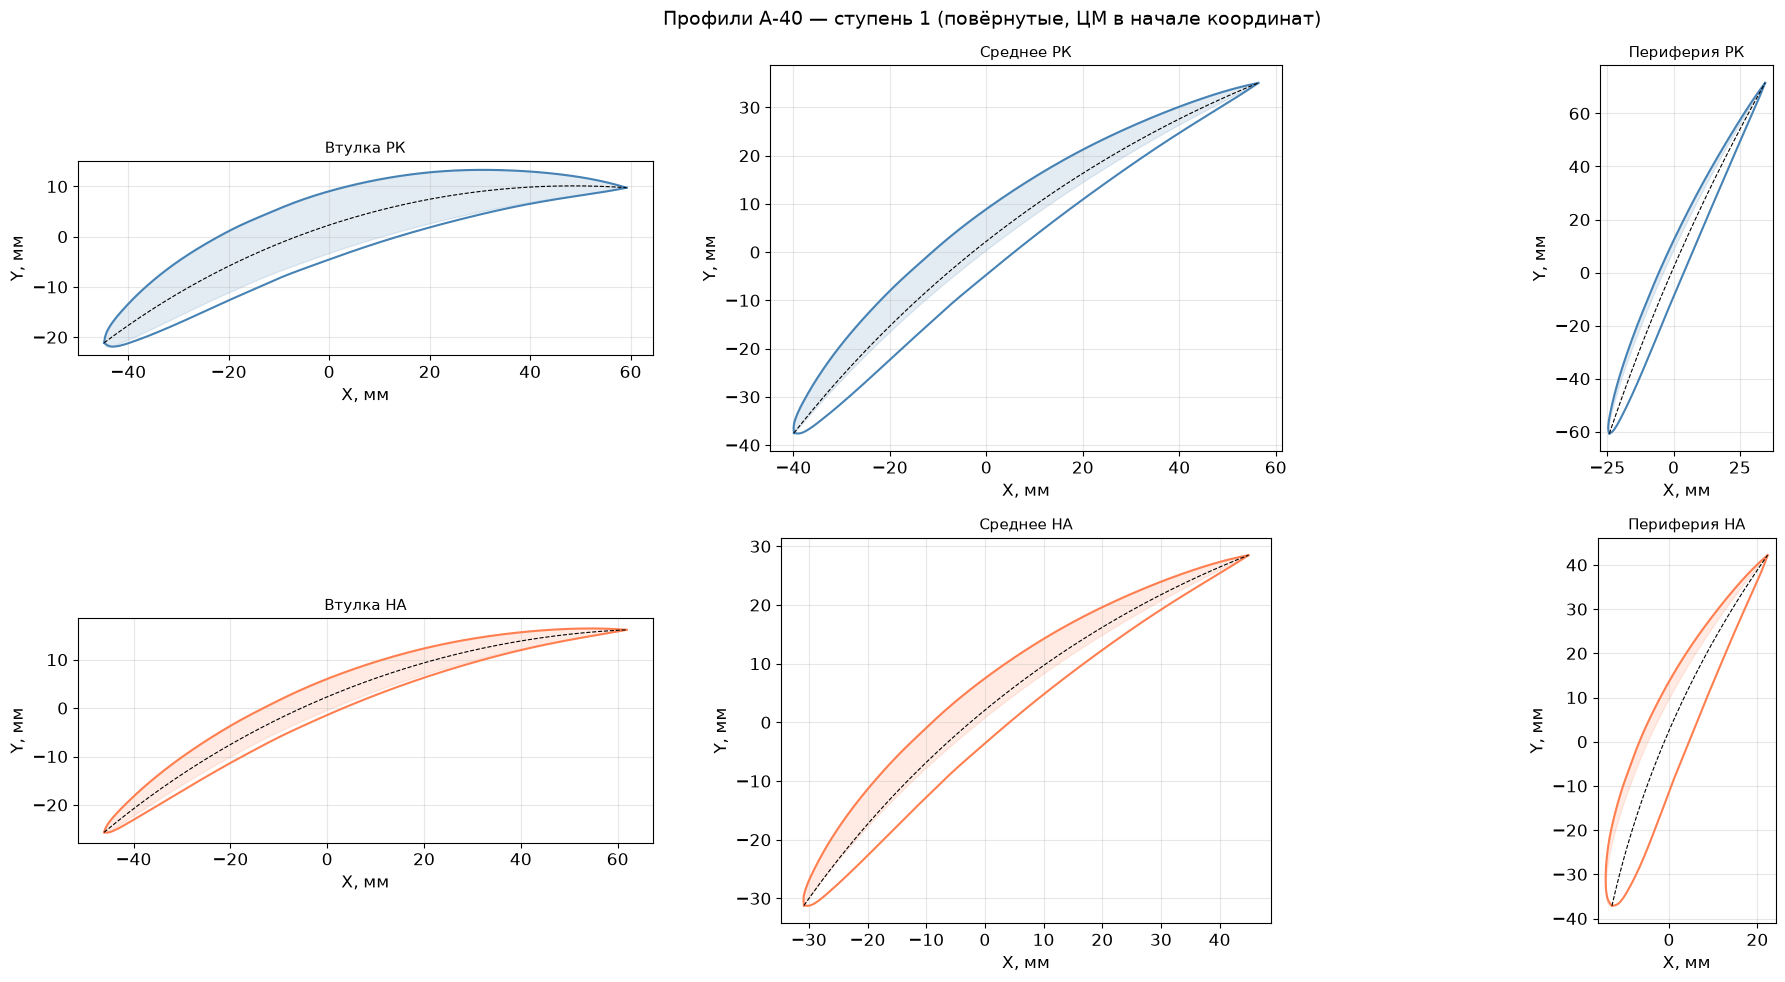

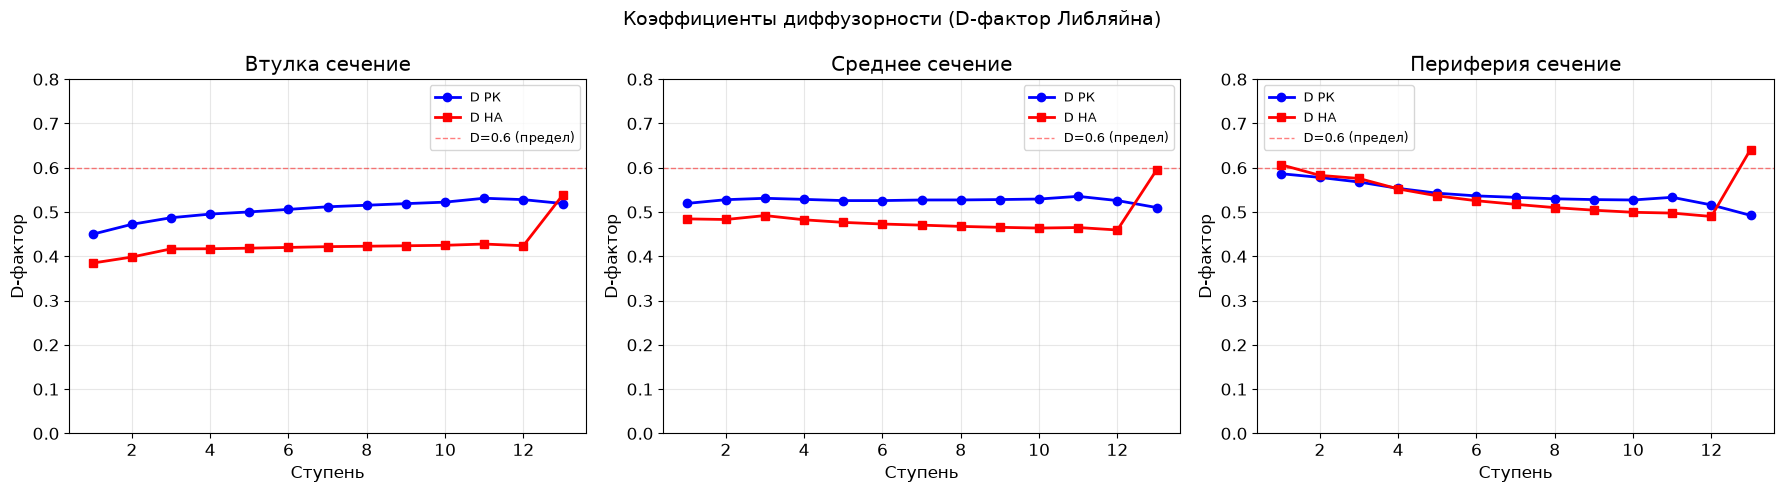

In [121]:
# ================================================
# ПОСТРОЕНИЕ ПРОФИЛЕЙ А-40 (1-я ступень, 6 сечений)
# ================================================

xb = xb_pct / 100.0
yb_base = yb_pct / 100.0
from scipy.interpolate import CubicSpline
spl_profile = CubicSpline(xb, yb_base)

def yb_func(x, c_prime):
    return spl_profile(x) * c_prime / 10.0

def y_midline(x, theta_deg):
    half_th = np.radians(theta_deg / 2.0)
    if abs(half_th) < 1e-6:
        return np.zeros_like(x)
    R_arc = 1.0 / (2.0 * np.sin(half_th))
    return np.sqrt(np.maximum(R_arc**2 - (x - 0.5)**2, 0)) - 0.5 / np.tan(half_th)

def build_profile(b_chord, theta_deg, c_prime, upsilon_deg, D_diam):
    x_rel = np.linspace(0, 1, 200)
    y_thick = yb_func(np.clip(x_rel, xb[0], xb[-1]), c_prime)
    y_mid = y_midline(x_rel, theta_deg)
    y_sp = y_mid + y_thick
    y_ko = y_mid - y_thick

    X = x_rel * b_chord * 1000
    Y_sp = y_sp * b_chord * 1000
    Y_ko = y_ko * b_chord * 1000
    Y_mid = y_mid * b_chord * 1000

    A = np.trapezoid(Y_sp - Y_ko, X)
    if abs(A) > 1e-6:
        Sx = 0.5 * np.trapezoid(Y_sp**2 - Y_ko**2, X)
        Sy = np.trapezoid(X * (Y_sp - Y_ko), X)
        xc, yc = Sy / A, Sx / A
    else:
        xc, yc = np.mean(X), np.mean(Y_mid)

    r_in  = 0.055 * c_prime / 100.0 * b_chord * 1000
    r_out = 0.05  * c_prime / 100.0 * b_chord * 1000

    ang = np.radians(90 - upsilon_deg)
    cos_a, sin_a = np.cos(ang), np.sin(ang)
    Xr_sp = X * cos_a - Y_sp * sin_a
    Yr_sp = X * sin_a + Y_sp * cos_a
    Xr_ko = X * cos_a - Y_ko * sin_a
    Yr_ko = X * sin_a + Y_ko * cos_a
    Xr_mid = X * cos_a - Y_mid * sin_a
    Yr_mid = X * sin_a + Y_mid * cos_a

    xc_r = xc * cos_a - yc * sin_a
    yc_r = xc * sin_a + yc * cos_a

    Xr_sp -= xc_r; Yr_sp -= yc_r
    Xr_ko -= xc_r; Yr_ko -= yc_r
    Xr_mid -= xc_r; Yr_mid -= yc_r

    r_blade = D_diam * 1000 / 2.0
    return {
        'X_sp': Xr_sp, 'Y_sp': Yr_sp,
        'X_ko': Xr_ko, 'Y_ko': Yr_ko,
        'X_mid': Xr_mid, 'Y_mid': Yr_mid,
        'xc': xc, 'yc': yc, 'A': A,
        'r_in': r_in, 'r_out': r_out,
        'r_blade': r_blade,
        'D_diam': D_diam,
    }

# Параметры для 1-й ступени (i=0)
i0 = 0
sections = [
    # (название, тип, c', θ, b, υ, D) — порядок: Dвт, Dср, Dп
    ("Втулка РК",      "RK", 12, theta_RK_3s[i0,0], 0.9*b_RK[i0],
     ups_RK_3s[i0,0], Dvt1_prof[i0]),
    ("Среднее РК",     "RK", 9, theta_RK_3s[i0,1], b_RK[i0],
     ups_RK_3s[i0,1], Dsr1_prof[i0]),
    ("Периферия РК",   "RK", 6, theta_RK_3s[i0,2], 1.2*b_RK[i0],
     ups_RK_3s[i0,2], Dk1_prof[i0]),
    ("Втулка НА",      "NA", 6, theta_NA_3s[i0,0], 1.2*b_NA[i0],
     ups_NA_3s[i0,0], Dvt2_prof[i0]),
    ("Среднее НА",     "NA", 9, theta_NA_3s[i0,1], b_NA[i0],
     ups_NA_3s[i0,1], Dsr2_prof[i0]),
    ("Периферия НА",   "NA", 12, theta_NA_3s[i0,2], 0.9*b_NA[i0],
     ups_NA_3s[i0,2], Dk2_prof[i0]),
]

profiles = {}
print("=" * 90)
print("ПАРАМЕТРЫ ПРОФИЛЕЙ А-40 — СТУПЕНЬ 1")
print("=" * 90)
print(f"{'Сечение':<18} {'c_bar,%':>7} {'θ,°':>7} {'b,мм':>7} {'υ,°':>7} "
      f"{'r,мм':>7} {'xc,мм':>7} {'yc,мм':>7} {'r_вх':>6} {'r_вых':>6}")
print("-" * 90)

for name, typ, c_pr, th, b_ch, ups, D_d in sections:
    p = build_profile(b_ch, th, c_pr, ups, D_d)
    profiles[name] = p
    print(f"{name:<18} {c_pr:>7d} {th:>7.1f} {b_ch*1000:>7.1f} {ups:>7.1f} "
          f"{p['r_blade']:>7.1f} {p['xc']:>7.1f} {p['yc']:>7.1f} "
          f"{p['r_in']:>6.3f} {p['r_out']:>6.3f}")

# --- Графики профилей ---
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for idx, (name, typ, c_pr, th, b_ch, ups, D_d) in enumerate(sections):
    ax = axes[idx // 3, idx % 3]
    p = profiles[name]
    ax.fill_between(p['X_sp'], p['Y_sp'], p['Y_ko'], alpha=0.15,
                    color='steelblue' if typ == 'RK' else 'coral')
    ax.plot(p['X_sp'], p['Y_sp'], '-', lw=1.5,
            color='steelblue' if typ == 'RK' else 'coral')
    ax.plot(p['X_ko'], p['Y_ko'], '-', lw=1.5,
            color='steelblue' if typ == 'RK' else 'coral')
    ax.plot(p['X_mid'], p['Y_mid'], 'k--', lw=0.8)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('X, мм')
    ax.set_ylabel('Y, мм')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('Профили А-40 — ступень 1 (повёрнутые, ЦМ в начале координат)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Графики D-фактора ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sec_labels = ['Втулка', 'Среднее', 'Периферия']
sec_j = [0, 1, 2]

for ax, sj, sl in zip(axes, sec_j, sec_labels):
    ax.plot(stages, D_RK_3s[:, sj], 'bo-', lw=2, label='D РК')
    ax.plot(stages, D_NA_3s[:, sj], 'rs-', lw=2, label='D НА')
    ax.axhline(0.6, color='red', ls='--', lw=1, alpha=0.5, label='D=0.6 (предел)')
    ax.set_xlabel('Ступень')
    ax.set_ylabel('D-фактор')
    ax.set_title(f'{sl} сечение')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 0.8)

fig.suptitle('Коэффициенты диффузорности (D-фактор Либляйна)', fontsize=14)
plt.tight_layout()
plt.show()


In [122]:
# ================================================
# ВЫВОД КООРДИНАТ ПРОФИЛЕЙ (X Y) — РК и НА, 3 сечения
# Порядок: Dвт, Dср, Dп
# Экспорт в txt: export/РК(НА)/Dвт(Dср,Dп)/спинка.txt и т.д.
# ================================================
import os

export_sections = [
    ("Втулка РК",     "Dвт", "РК"),
    ("Среднее РК",    "Dср", "РК"),
    ("Периферия РК",  "Dп",  "РК"),
    ("Втулка НА",     "Dвт", "НА"),
    ("Среднее НА",    "Dср", "НА"),
    ("Периферия НА",  "Dп",  "НА"),
]

lines_out = [
    ("Спинка",        "X_sp",  "Y_sp",  "спинка.txt"),
    ("Корыто",        "X_ko",  "Y_ko",  "корыто.txt"),
    ("Средняя линия", "X_mid", "Y_mid", "средняя_линия.txt"),
]

for sec_name, d_label, blade_type in export_sections:
    p = profiles[sec_name]
    D_mm = p['D_diam'] * 1000

    folder = os.path.join("export", blade_type, d_label)
    os.makedirs(folder, exist_ok=True)

    for line_name, xk, yk, fname in lines_out:
        filepath = os.path.join(folder, fname)
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(f"# {sec_name} | Диаметр: {d_label} = {D_mm:.1f} мм | Линия: {line_name}\n")
            f.write(f"# X, мм    Y, мм\n")
            for x, y in zip(p[xk], p[yk]):
                f.write(f"{x:.4f} {y:.4f}\n")

        print(f"  {filepath}")

    print(f"\n{'='*50}")
    print(f"Диаметр: {d_label} = {D_mm:.1f} мм ({sec_name})")
    print(f"{'='*50}")
    for line_name, xk, yk, fname in lines_out:
        print(f"  {line_name}: {len(p[xk])} точек → export/{blade_type}/{d_label}/{fname}")

print(f"\nЭкспорт завершён в папку export/")


  export/РК/Dвт/спинка.txt
  export/РК/Dвт/корыто.txt
  export/РК/Dвт/средняя_линия.txt

Диаметр: Dвт = 385.8 мм (Втулка РК)
  Спинка: 200 точек → export/РК/Dвт/спинка.txt
  Корыто: 200 точек → export/РК/Dвт/корыто.txt
  Средняя линия: 200 точек → export/РК/Dвт/средняя_линия.txt
  export/РК/Dср/спинка.txt
  export/РК/Dср/корыто.txt
  export/РК/Dср/средняя_линия.txt

Диаметр: Dср = 610.0 мм (Среднее РК)
  Спинка: 200 точек → export/РК/Dср/спинка.txt
  Корыто: 200 точек → export/РК/Dср/корыто.txt
  Средняя линия: 200 точек → export/РК/Dср/средняя_линия.txt
  export/РК/Dп/спинка.txt
  export/РК/Dп/корыто.txt
  export/РК/Dп/средняя_линия.txt

Диаметр: Dп = 771.6 мм (Периферия РК)
  Спинка: 200 точек → export/РК/Dп/спинка.txt
  Корыто: 200 точек → export/РК/Dп/корыто.txt
  Средняя линия: 200 точек → export/РК/Dп/средняя_линия.txt
  export/НА/Dвт/спинка.txt
  export/НА/Dвт/корыто.txt
  export/НА/Dвт/средняя_линия.txt

Диаметр: Dвт = 428.9 мм (Втулка НА)
  Спинка: 200 точек → export/НА/Dвт/сп

ОСЕВЫЕ РАЗМЕРЫ СТУПЕНЕЙ (на среднем радиусе)
 Ступ   Sрк,мм  Sрк_заз   Sна,мм  Sна_заз  Σступ,мм
--------------------------------------------------------------------------------
    1    74.67    14.93    58.29    11.66    159.55
    2    57.16    11.43    44.36     8.87    121.82
    3    44.47     8.89    34.32     6.86     94.54
    4    35.86     7.17    27.52     5.50     76.06
    5    29.85     5.97    22.78     4.56     63.16
    6    25.46     5.09    19.32     3.86     53.73
    7    22.15     4.43    16.70     3.34     46.62
    8    19.59     3.92    14.67     2.93     41.11
    9    17.57     3.51    13.07     2.61     36.76
   10    15.95     3.19    11.78     2.36     33.28
   11    14.69     2.94    10.77     2.15     30.56
   12    13.56     2.71    10.32     2.06     28.66
   13    12.58     2.52    10.19     2.04     27.32
                                             813.18  ИТОГО


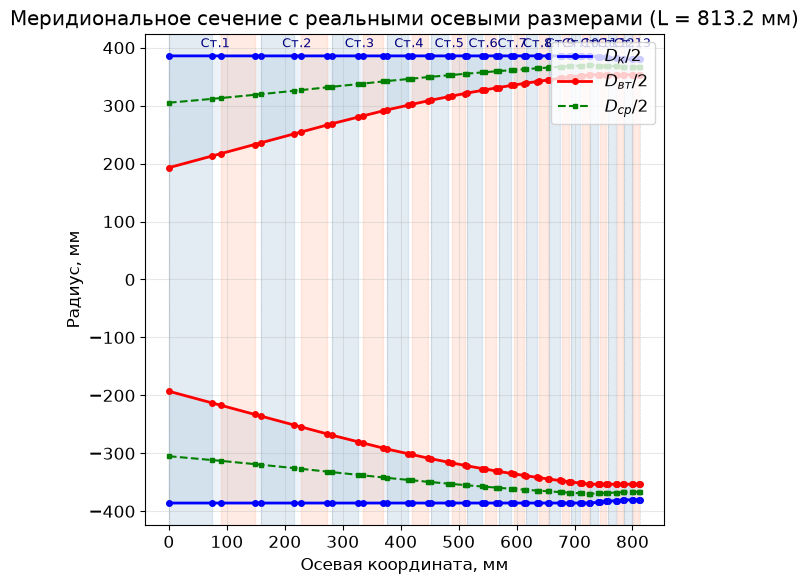


Линия Dвт/2 (53 точек) сохранена в export/Dвт_line.txt


In [123]:
# ================================================
# МЕРИДИОНАЛЬНОЕ СЕЧЕНИЕ С РЕАЛЬНЫМИ ОСЕВЫМИ РАЗМЕРАМИ
# Sрк = b_РК * sin(β1), Sна = b_НА * sin(α2)
# Зазоры: 0.2 от осевого размера лопатки
# ================================================

# Осевые размеры лопаток (средний радиус, j=1)
S_RK = b_RK * np.sin(bt1_r[:, 1])       # осевая проекция РК
S_NA = b_NA * np.sin(al2_r[:, 1])        # осевая проекция НА
S_RK_gap = 0.2 * S_RK                    # зазор после РК
S_NA_gap = 0.2 * S_NA                    # зазор после НА

# Таблица осевых размеров
print("=" * 80)
print("ОСЕВЫЕ РАЗМЕРЫ СТУПЕНЕЙ (на среднем радиусе)")
print("=" * 80)
print(f"{'Ступ':>5} {'Sрк,мм':>8} {'Sрк_заз':>8} {'Sна,мм':>8} {'Sна_заз':>8} {'Σступ,мм':>9}")
print("-" * 80)
for i in range(Z):
    total = (S_RK[i] + S_RK_gap[i] + S_NA[i] + S_NA_gap[i]) * 1000
    print(f"{i+1:>5d} {S_RK[i]*1000:>8.2f} {S_RK_gap[i]*1000:>8.2f} "
          f"{S_NA[i]*1000:>8.2f} {S_NA_gap[i]*1000:>8.2f} {total:>9.2f}")
L_total = np.sum(S_RK + S_RK_gap + S_NA + S_NA_gap)
print(f"{'':>5} {'':>8} {'':>8} {'':>8} {'':>8} {L_total*1000:>9.2f}  ИТОГО")

# Построение точек меридионального контура
x_pts = [0.0]
dvt_pts = [Dvt_arr[0]]
dk_pts = [Dk_arr[0]]

for i in range(Z):
    x0 = x_pts[-1]
    stage_len = S_RK[i] + S_RK_gap[i] + S_NA[i] + S_NA_gap[i]

    fracs = np.array([
        S_RK[i],
        S_RK[i] + S_RK_gap[i],
        S_RK[i] + S_RK_gap[i] + S_NA[i],
        stage_len,
    ]) / stage_len

    for f in fracs:
        x_pts.append(x0 + f * stage_len)
        dvt_pts.append(Dvt_arr[i] + f * (Dvt_arr[i+1] - Dvt_arr[i]))
        dk_pts.append(Dk_arr[i] + f * (Dk_arr[i+1] - Dk_arr[i]))

x_mm = np.array(x_pts) * 1000
dvt_mm = np.array(dvt_pts) * 1000
dk_mm = np.array(dk_pts) * 1000
dsr_mm = np.sqrt((dvt_mm**2 + dk_mm**2) / 2.0)

# --- График ---
fig, ax = plt.subplots(1, 1, figsize=(18, 6))

ax.plot(x_mm, dk_mm / 2, 'b-o', lw=2, ms=4, label='$D_к/2$')
ax.plot(x_mm, dvt_mm / 2, 'r-o', lw=2, ms=4, label='$D_{вт}/2$')
ax.plot(x_mm, dsr_mm / 2, 'g--s', lw=1.5, ms=3, label='$D_{ср}/2$')

ax.plot(x_mm, -dk_mm / 2, 'b-o', lw=2, ms=4)
ax.plot(x_mm, -dvt_mm / 2, 'r-o', lw=2, ms=4)
ax.plot(x_mm, -dsr_mm / 2, 'g--s', lw=1.5, ms=3)

ax.fill_between(x_mm, dvt_mm / 2, dk_mm / 2, alpha=0.1, color='steelblue')
ax.fill_between(x_mm, -dvt_mm / 2, -dk_mm / 2, alpha=0.1, color='steelblue')

# Раскраска зон: РК, зазор, НА, зазор
x_cum = 0.0
for i in range(Z):
    segs = [S_RK[i], S_RK_gap[i], S_NA[i], S_NA_gap[i]]
    colors = ['steelblue', 'none', 'coral', 'none']
    labels_seg = ['РК', 'зазор', 'НА', 'зазор']
    alphas = [0.15, 0, 0.15, 0]

    for seg, col, alp, lbl in zip(segs, colors, alphas, labels_seg):
        x1 = x_cum * 1000
        x2 = (x_cum + seg) * 1000
        if alp > 0:
            y_top = max(dk_mm) / 2 + 20
            ax.axvspan(x1, x2, alpha=alp, color=col)
        x_cum += seg

    mid_x = (x_cum - sum(segs)/2) * 1000
    ax.text(mid_x, max(dk_mm)/2 + 15, f'Ст.{i+1}', ha='center', fontsize=9, color='navy')

# Вертикальные линии на границах ступеней
x_cum = 0.0
for i in range(Z + 1):
    ax.axvline(x_cum * 1000, color='gray', ls=':', lw=0.5, alpha=0.5)
    if i < Z:
        x_cum += S_RK[i] + S_RK_gap[i] + S_NA[i] + S_NA_gap[i]

ax.set_xlabel('Осевая координата, мм')
ax.set_ylabel('Радиус, мм')
ax.set_title(f'Меридиональное сечение с реальными осевыми размерами '
             f'(L = {L_total*1000:.1f} мм)')
ax.legend(loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- Экспорт линии Dвт/2 в файл ---
os.makedirs('export', exist_ok=True)
with open(os.path.join('export', 'Dвт_line.txt'), 'w', encoding='utf-8') as f:
    f.write("# Линия Dвт/2 меридионального сечения\n")
    f.write("# X, мм    Dвт/2, мм\n")
    for x, d in zip(x_mm, dvt_mm / 2):
        f.write(f"{x:.4f} {d:.4f}\n")
print(f"\nЛиния Dвт/2 ({len(x_mm)} точек) сохранена в export/Dвт_line.txt")


## 12. Итоговая сводка

In [124]:
print("=" * 70)
print("ИТОГОВАЯ СВОДКА РАСЧЁТА ОСЕВОГО КОМПРЕССОРА")
print("=" * 70)
print()
print("--- Исходные данные ---")
print(f"  G       = {G} кг/с")
print(f"  T*_0    = {T0_star} К")
print(f"  P*_0    = {P0_star:.0f} Па")
print(f"  pi*_к   = {pi_k_star}")
print(f"  n       = {n_rpm} об/мин")
print()
print("--- Оптимизированные параметры 1-й ступени ---")
print(f"  c_a_bar = {ca_bar_1:.4f}     (коэфф. расхода)")
print(f"  d_bar_1 = {d_bar_1:.4f}     (относит. диаметр втулки)")
print(f"  H_T_bar = {HT_bar_1:.4f}     (коэфф. напора)")
print(f"  R_ср    = {R_sr_base}        (степень реактивности)")
print()
print("--- Размеры ---")
print(f"  D_к_1   = {D_k*1000:.0f} мм        (наружный диаметр 1-й ст.)")
print(f"  D_вт_1  = {D_vt_1*1000:.0f} мм        (диаметр втулки 1-й ст.)")
print(f"  h_1     = {h_1*1000:.1f} мм       (высота лопатки 1-й ст.)")
h_n_final = (Dk_arr[Z] - Dvt_arr[Z]) / 2.0
print(f"  h_n     = {h_n_final*1000:.1f} мм       (высота лопатки посл. ст.)")
print(f"  D_к_n   = {Dk_arr[Z]*1000:.1f} мм     (наружный диаметр посл. ст.)")
print(f"  d_bar_n = {d3_bar[Z-1]:.4f}     (относит. диам. втулки посл. ст.)")
if i_switch >= 0:
    print(f"  Переключение Dk→Dvt: ступень {i_switch+1}")
    print(f"  D_вт (frozen) = {D_vt_frozen*1000:.1f} мм")
print()
print("--- Результаты ---")
print(f"  Z       = {Z}             (число ступеней)")
print(f"  u_к_1   = {u_k:.1f} м/с     (окружная скорость конца лопатки 1-й ст.)")
print(f"  pi*_к   = {pi_k_calc:.2f}        (степень повышения давления)")
print(f"  eta*_к  = {eta_k_calc:.4f}      (КПД компрессора)")
print(f"  T*_вых  = {T1s[Z]:.1f} К      (температура на выходе)")
print(f"  P*_вых  = {P1s[Z]/1000:.1f} кПа    (давление на выходе)")
print(f"  N_к     = {N_k:.0f} кВт = {N_k/1000:.1f} МВт  (мощность привода)")
print(f"  M_w1_tip= {Mw1_sr[0] * u_k / (rcp1[0]*u_k) * D_k/2 / (D_sr_1/2):.3f}  (число М на конце 1-й ст.)")
print()
print("--- Невязка ---")
print(f"  Δπ*     = {delta_pi:+.2f}%")
print()
print("Расчёт выполнен по методике В.С. Бекнева (МВТУ, 1981)")
print("Форма проточной части: комбинированный (Dk=const → Dvt=const)")


ИТОГОВАЯ СВОДКА РАСЧЁТА ОСЕВОГО КОМПРЕССОРА

--- Исходные данные ---
  G       = 58.7 кг/с
  T*_0    = 288.0 К
  P*_0    = 101300 Па
  pi*_к   = 18.2
  n       = 8600 об/мин

--- Оптимизированные параметры 1-й ступени ---
  c_a_bar = 0.4500     (коэфф. расхода)
  d_bar_1 = 0.5000     (относит. диаметр втулки)
  H_T_bar = 0.3221     (коэфф. напора)
  R_ср    = 0.5        (степень реактивности)

--- Размеры ---
  D_к_1   = 772 мм        (наружный диаметр 1-й ст.)
  D_вт_1  = 386 мм        (диаметр втулки 1-й ст.)
  h_1     = 192.9 мм       (высота лопатки 1-й ст.)
  h_n     = 26.5 мм       (высота лопатки посл. ст.)
  D_к_n   = 759.6 мм     (наружный диаметр посл. ст.)
  d_bar_n = 0.9302     (относит. диам. втулки посл. ст.)
  Переключение Dk→Dvt: ступень 11
  D_вт (frozen) = 706.6 мм

--- Результаты ---
  Z       = 13             (число ступеней)
  u_к_1   = 347.4 м/с     (окружная скорость конца лопатки 1-й ст.)
  pi*_к   = 18.05        (степень повышения давления)
  eta*_к  = 0.7934  

In [125]:
# ================================================
# ЭКСПОРТ ТАБЛИЦ ПРИЛОЖЕНИЙ В XLSX
# (Приложение А, Б, В — по структуре tables_export.md)
# ================================================
import os
os.makedirs('export', exist_ok=True)

try:
    import openpyxl
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl', '-q'])
    import openpyxl

from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, Border, Side

thin = Side(style='thin')
border = Border(left=thin, right=thin, top=thin, bottom=thin)
bold = Font(bold=True)
center = Alignment(horizontal='center', vertical='center', wrap_text=True)

def write_header(ws, row, headers, units=None):
    for col, h in enumerate(headers, 1):
        c = ws.cell(row=row, column=col, value=h)
        c.font = bold
        c.alignment = center
        c.border = border
    if units:
        for col, u in enumerate(units, 1):
            c = ws.cell(row=row+1, column=col, value=u)
            c.alignment = center
            c.border = border

def write_data(ws, start_row, data_rows):
    for r, row_data in enumerate(data_rows, start_row):
        for col, val in enumerate(row_data, 1):
            c = ws.cell(row=r, column=col, value=val)
            c.border = border
            c.alignment = Alignment(horizontal='center')

# Предвычисление недостающих величин
omega = 2.0 * np.pi * n_rpm / 60.0
u_k_stages = np.pi * Dk_arr[:Z] * n_rpm / 60.0
Dsr_arr = np.sqrt((Dk_arr**2 + Dvt_arr**2) / 2.0)

# Плотности
rho1_arr = np.zeros(Z)
rho3_arr = np.zeros(Z)
c1_sr = np.zeros(Z)
w2_sr = np.zeros(Z)
T1_stat_arr = np.zeros(Z)
T2_arr = np.zeros(Z)
d2_bar = np.zeros(Z)

for i in range(Z):
    k_i = k_st[i]
    rho1_arr[i] = P1s[i] / (Rg * T1s[i]) * eps_lam(lam1[i], k_i)
    k_i3 = k_air(T1s[i+1], Rg)
    lam3 = ca2_dim[i] / (np.sin(alpha3[i]) * acr3[i])
    rho3_arr[i] = P1s[i+1] / (Rg * T1s[i+1]) * eps_lam(lam3, k_i3)
    c1_sr[i] = ca1_dim[i] / np.sin(alpha1[i]) if np.sin(alpha1[i]) > 0.01 else ca1_dim[i]
    w2_sr[i] = ca2_dim[i] / np.sin(beta2[i]) if np.sin(beta2[i]) > 0.01 else ca2_dim[i]
    T1_stat_arr[i] = T1s[i] * tau_lam(lam1[i], k_i)
    lam_c2 = c2[i] / acr3[i]
    T2_arr[i] = T1s[i+1] * tau_lam(lam_c2, k_i3)
    Dk2_i = 0.5*(Dk_arr[i] + Dk_arr[i+1])
    Dvt2_i = 0.5*(Dvt_arr[i] + Dvt_arr[i+1])
    d2_bar[i] = Dvt2_i / Dk2_i

Uk3 = np.pi * Dk_arr[1:Z+1] * n_rpm / 60.0
cu3_bar_arr = np.zeros(Z)
ca3_bar_arr = np.zeros(Z)
ca3_dim_arr = np.zeros(Z)
for i in range(Z):
    rcp3_i = np.sqrt((1.0 + d3_bar[i]**2) / 2.0)
    if i < Z - 1:
        cu3_bar_arr[i] = rcp3_i * (1.0 - R_dist[i+1]) - HT_bar_dist[i+1] / (2.0 * rcp3_i)
        ca3_bar_arr[i] = ca_bar_dist[i+1]
    else:
        cu3_bar_arr[i] = cu1_bar[i]
        ca3_bar_arr[i] = ca2_bar[i]
    ca3_dim_arr[i] = ca3_bar_arr[i] * u_k_stages[min(i+1, Z-1)] if i < Z-1 else ca2_dim[i]

lam3_arr = np.zeros(Z)
for i in range(Z):
    lam3_arr[i] = ca2_dim[i] / (np.sin(alpha3[i]) * acr3[i]) if np.sin(alpha3[i]) > 0.01 else 0

delta_ca = np.zeros(Z)
delta_ca[0] = ca1_dim[0] - ca2_dim[0]
for i in range(1, Z):
    delta_ca[i] = ca1_dim[i] - ca2_dim[i]

# =============================================
# ПРИЛОЖЕНИЕ А
# =============================================
wb_a = Workbook()
ws = wb_a.active
ws.title = "Приложение А"

headers_a = [
    "№ ступени",
    "Dк1, м", "Dcp1, м", "Dвт1, м", "Uk1, м/с",
    "c'a1", "ca1, м/с", "η*ад", "H'т", "Kh", "Rcp", "d'1",
    "α1, °", "Hт, Дж/кг", "Lz, Дж/кг", "Над, Дж/кг",
    "T*3, К", "P*1, кПа", "P*3, кПа", "π*",
    "акр1, м/с", "ρ*1, кг/м³", "r'cp1", "c'u1", "λ1",
    "F1, м²", "λ3", "F3, м²", "d'3", "r'cp3", "Uk3, м/с", "c'u3",
    "α3, °", "c'a3", "ca3, м/с", "Δca, м/с", "ρ*3, кг/м³",
    "r'cp2", "c'a2", "c'u2", "α2, °",
    "β1, °", "β2, °", "εрк, °", "εна, °",
    "Uk2, м/с", "ca2, м/с", "c1, м/с",
    "c2, м/с", "W1, м/с", "W2, м/с",
    "T*2, К", "T1, К", "Mw1", "Mc2cp", "d'2"
]

write_header(ws, 1, headers_a)

Uk2_arr = np.pi * 0.5*(Dk_arr[:Z] + Dk_arr[1:Z+1]) * n_rpm / 60.0

for i in range(Z):
    row_data = [
        i,
        round(Dk_arr[i], 4), round(Dsr_arr[i], 4), round(Dvt_arr[i], 4),
        round(u_k_stages[i], 2),
        round(ca_bar_dist[i], 4), round(ca1_dim[i], 1),
        round(eta_dist[i], 4), round(HT_bar_dist[i], 4),
        round(K_H_dist[i], 3), round(R_dist[i], 3), round(d1_bar[i], 4),
        round(np.degrees(alpha1[i]), 3),
        round(HT_dim[i], 3), round(Lz[i], 3), round(Had[i], 3),
        round(T1s[i+1], 1), round(P1s[i]/1000, 3), round(P1s[i+1]/1000, 3),
        round(pi_st[i], 4),
        round(acr1[i], 3), round(rho1_arr[i], 3),
        round(rcp1[i], 4), round(cu1_bar[i], 4), round(lam1[i], 4),
        round(F1[i], 4), round(lam3_arr[i], 4), round(F3[i], 4),
        round(d3_bar[i], 4), round(rcp3[i], 4),
        round(Uk3[i], 2), round(cu3_bar_arr[i], 4),
        round(np.degrees(alpha3[i]), 3),
        round(ca3_bar_arr[i], 4), round(ca3_dim_arr[i], 1),
        round(delta_ca[i], 3), round(rho3_arr[i], 3),
        round(rcp2[i], 4), round(ca2_bar[i], 4), round(cu2_bar[i], 4),
        round(np.degrees(alpha2[i]), 3),
        round(np.degrees(beta1[i]), 3), round(np.degrees(beta2[i]), 3),
        round(np.degrees(eps_RK[i]), 3), round(np.degrees(eps_NA[i]), 3),
        round(Uk2_arr[i], 2), round(ca2_dim[i], 1), round(c1_sr[i], 3),
        round(c2[i], 3), round(w1[i], 3), round(w2_sr[i], 3),
        round(T1s[i+1], 1), round(T1_stat_arr[i], 1),
        round(Mw1_sr[i], 3), round(Mc2_sr[i], 3), round(d2_bar[i], 4),
    ]
    for col, val in enumerate(row_data, 1):
        c = ws.cell(row=i+2, column=col, value=val)
        c.border = border
        c.alignment = Alignment(horizontal='center')

for col in ws.columns:
    ws.column_dimensions[col[0].column_letter].width = 14

wb_a.save(os.path.join('export', 'Приложение_А.xlsx'))
print("Приложение А → export/Приложение_А.xlsx")

# =============================================
# ПРИЛОЖЕНИЕ Б
# =============================================
wb_b = Workbook()

sec_names_b = ['Втулочное', 'Среднее', 'Периферийное']
sec_idx_b = [0, 1, 2]

headers_b1 = [
    "№ ступени",
    "U1, м/с", "U2, м/с", "U3, м/с",
    "ca1, м/с", "ca2, м/с", "ca3, м/с",
    "cu1, м/с", "cu2, м/с", "cu3, м/с",
    "c1, м/с", "c2, м/с", "c3, м/с",
    "w1, м/с", "w2, м/с",
    "α1, °", "α2, °", "α3, °",
    "β1, °", "β2, °",
    "εрк, °", "εна, °", "Mw1"
]

for sn, si in zip(sec_names_b, sec_idx_b):
    ws = wb_b.create_sheet(title=sn)
    write_header(ws, 1, headers_b1)

    for i in range(Z):
        Mw1_loc = w1_r[i, si] / (np.sqrt(k_st[i] * Rg * T1s[i] * tau_lam(
            w1_r[i, si] / acr1[i], k_st[i]))) if T1s[i] > 0 else 0

        row_data = [
            i + 1,
            round(u1_r[i, si], 3), round(u2_r[i, si], 3), round(u3_r[i, si], 3),
            round(c1a_r[i, si], 3), round(c2a_r[i, si], 3), round(c3a_r[i, si], 3),
            round(c1u_r[i, si], 3), round(c2u_r[i, si], 3), round(c3u_r[i, si], 3),
            round(c1_r[i, si], 3), round(c2_r[i, si], 3), round(c3_r[i, si], 3),
            round(w1_r[i, si], 3), round(w2_r[i, si], 3),
            round(np.degrees(al1_r[i, si]), 3),
            round(np.degrees(al2_r[i, si]), 3),
            round(np.degrees(al3_r[i, si]), 3),
            round(np.degrees(bt1_r[i, si]), 3),
            round(np.degrees(bt2_r[i, si]), 3),
            round(np.degrees(bt2_r[i, si] - bt1_r[i, si]), 3),
            round(np.degrees(al3_r[i, si] - al2_r[i, si]), 3),
            round(Mw1_loc, 3),
        ]
        for col, val in enumerate(row_data, 1):
            c = ws.cell(row=i+2, column=col, value=val)
            c.border = border
            c.alignment = Alignment(horizontal='center')

    for col in ws.columns:
        ws.column_dimensions[col[0].column_letter].width = 12

if 'Sheet' in wb_b.sheetnames:
    del wb_b['Sheet']
wb_b.save(os.path.join('export', 'Приложение_Б.xlsx'))
print("Приложение Б → export/Приложение_Б.xlsx")

# =============================================
# ПРИЛОЖЕНИЕ В
# =============================================
wb_v = Workbook()
ws = wb_v.active
ws.title = "Приложение В"

headers_v = [
    "№ ступени",
    "β1cp, °", "β2cp, °", "εрк.cp, °",
    "α2cp, °", "α3cp, °", "εна.cp, °",
    "iрк.cp, °", "iна.cp, °",
    "θрк.cp, °", "θна.cp, °",
    "δрк.cp, °", "δна.cp, °",
    "υрк.cp, °", "υна.cp, °",
    "hрк, мм", "hна, мм",
    "bрк, мм", "bна, мм",
    "tрк.cp, мм", "tна.cp, мм",
    "b/tрк.cp", "b/tна.cp",
    "zрк", "zна",
    "Sрк.cp, мм", "Sна.cp, мм",
    "S1 (зазор), мм", "S2 (зазор), мм"
]

write_header(ws, 1, headers_v)

S_RK_axial = b_RK * np.sin(bt1_r[:, 1])
S_NA_axial = b_NA * np.sin(al2_r[:, 1])
S_RK_gap = 0.2 * S_RK_axial
S_NA_gap = 0.2 * S_NA_axial

for i in range(Z):
    j = 1  # средний радиус

    h_rk_i = (Dk_arr[i] - Dvt_arr[i]) / 2.0
    h_na_i = (0.5*(Dk_arr[i]+Dk_arr[i+1]) - 0.5*(Dvt_arr[i]+Dvt_arr[i+1])) / 2.0

    row_data = [
        i + 1,
        round(np.degrees(bt1_r[i, j]), 3),
        round(np.degrees(bt2_r[i, j]), 3),
        round(np.degrees(bt2_r[i, j] - bt1_r[i, j]), 3),
        round(np.degrees(al2_r[i, j]), 3),
        round(np.degrees(al3_r[i, j]), 3),
        round(np.degrees(al3_r[i, j] - al2_r[i, j]), 3),
        round(i_RK_3s[i, j], 4),
        round(i_NA_3s[i, j], 4),
        round(theta_RK_3s[i, j], 3),
        round(theta_NA_3s[i, j], 3),
        round(delta_RK_3s[i, j], 3),
        round(delta_NA_3s[i, j], 3),
        round(ups_RK_3s[i, j], 3),
        round(ups_NA_3s[i, j], 3),
        round(h_rk_i * 1000, 4),
        round(h_na_i * 1000, 4),
        round(b_RK[i] * 1000, 4),
        round(b_NA[i] * 1000, 4),
        round(t_RK_sr_a[i] * 1000, 4),
        round(t_NA_sr_a[i] * 1000, 4),
        round(bt_RK_sr_arr[i], 4),
        round(bt_NA_sr_arr[i], 4),
        int(Z_RK_blades[i]),
        int(Z_NA_blades[i]),
        round(S_RK_axial[i] * 1000, 3),
        round(S_NA_axial[i] * 1000, 3),
        round(S_RK_gap[i] * 1000, 3),
        round(S_NA_gap[i] * 1000, 3),
    ]
    for col, val in enumerate(row_data, 1):
        c = ws.cell(row=i+2, column=col, value=val)
        c.border = border
        c.alignment = Alignment(horizontal='center')

for col in ws.columns:
    ws.column_dimensions[col[0].column_letter].width = 14

wb_v.save(os.path.join('export', 'Приложение_В.xlsx'))
print("Приложение В → export/Приложение_В.xlsx")

print("\nЭкспорт всех приложений завершён!")


Приложение А → export/Приложение_А.xlsx
Приложение Б → export/Приложение_Б.xlsx
Приложение В → export/Приложение_В.xlsx

Экспорт всех приложений завершён!
